## Dictionary: Please read before running code and editing/commenting

1. Hypothesis:
An LSTM model will improve heat vulnerability prediction in NYC by classifying ZIP-code-days into five vulnerability levels using recent temporal patterns in temperature, 311 heat complaints, infrastructure, density, population, and energy usage.

2. Machine learning formulation:
This project is a supervised multi-class classification task. The model predicts a project-defined temporal heat vulnerability class for each ZIP-code-day.

3. Input (X):
For the LSTM, each input is a 7-day sequence of ZIP-code-level observations. Each day includes seven features: 311 heat complaint count, maximum temperature, street tree count, population density, population, water fountain count, and natural gas usage. For the baseline models, the same seven features are used as single-day flat observations.

4. Output (Y):
The output is a temporal heat vulnerability class from 1 lowest to 5 highest. This label is constructed by creating a composite daily risk signal and binning it into five percentile-based classes. The official NYC HVI is not the direct prediction target. Instead, it is used as a reference benchmark for interpretation.

5. Objective function:
to minimize classification error across the five temporal heat vulnerability classes.

6. Primary deep learning component:
The final model is an LSTM with a 7-day lookback window, dropout regularization, and a softmax output layer. The LSTM is the core deep learning component because it processes ordered daily sequences and can retain information from prior days when classifying current heat vulnerability.

7. Why LSTM:
A single-day model treats each ZIP-code-day as independent. The LSTM instead receives a sequence of recent observations, allowing it to learn whether vulnerability depends on cumulative heat exposure, lagged complaint patterns, or multi-day infrastructure and energy-use signals. This directly tests whether temporal structure improves heat vulnerability prediction.

8. Baseline models:
Decision Tree, Random Forest, and XGBoost are used as non-temporal baselines. They use the same feature set but flatten the data into single-day observations, so they serve as cross-sectional benchmarks against the sequence-based LSTM.

9. Evaluation metrics:
Accuracy, Macro F1, Weighted F1, and Mean Absolute Class Error are evaluated on a held-out 2025 temporal test set. Accuracy measures overall correctness, Macro F1 checks performance across classes more evenly, Weighted F1 accounts for class imbalance, and Mean Absolute Class Error measures how far off predictions are on the 1–5 ordinal vulnerability scale.

10. Ablation or sensitivity analysis:
We compare LSTM performance across different lookback windows, such as 1 day, 3 days, 7 days, and 14 days.

11. Core project contribution:
This project investigates whether temporal sequence modeling improves dynamic vulnerability classification compared with strong non-temporal baselines.



## Section 1: Making Baseline Comparison Model (XGBoost, Decision Tree, Random Forest)

In [ ]:
import numpy as np
import matplotlib.dates as mdates
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    mean_absolute_error,
    ConfusionMatrixDisplay
)
import os
import shutil
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import time 
from IPython.display import display
from math import sqrt
import json
import pickle
from pathlib import Path
from scipy.stats import t


# if running on CoLab:
#from google.colab import files
#uploaded = files.upload()
#os.makedirs("data", exist_ok=True)
#shutil.move("data_NAandSteamOmitted.csv", "data/data_NAandSteamOmitted.csv")

df = pd.read_csv("data/data_NAandSteamOmitted.csv")
df.head()

,Unnamed: 0,zip,date,call_count,HVI,fountains,gas_therms,tree_count,population_density,population,max_temp
0,1,10001,2018-05-15,0,2,15,16971904,911,26111.88,17310,76
1,2,10001,2018-05-16,0,2,15,16971904,911,26111.88,17310,65
2,3,10001,2018-05-17,0,2,15,16971904,911,26111.88,17310,67
3,4,10001,2018-05-18,0,2,15,16971904,911,26111.88,17310,64
4,5,10001,2018-05-19,0,2,15,16971904,911,26111.88,17310,57


In [2]:
# Dataset inspection
print(df.columns.tolist())
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

# prep data formats
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

['Unnamed: 0', 'zip', 'date', 'call_count', 'HVI', 'fountains', 'gas_therms', 'tree_count', 'population_density', 'population', 'max_temp']
(163515, 11)
   Unnamed: 0    zip        date  call_count  HVI  fountains  gas_therms  \
0           1  10001  2018-05-15           0    2         15    16971904   
1           2  10001  2018-05-16           0    2         15    16971904   
2           3  10001  2018-05-17           0    2         15    16971904   
3           4  10001  2018-05-18           0    2         15    16971904   
4           5  10001  2018-05-19           0    2         15    16971904   

   tree_count  population_density  population  max_temp  
0         911            26111.88       17310        76  
1         911            26111.88       17310        65  
2         911            26111.88       17310        67  
3         911            26111.88       17310        64  
4         911            26111.88       17310        57  
<class 'pandas.DataFrame'>
RangeIndex: 163

In [3]:
# ============================================================
# 1. CREATE TEMPORAL HVI TARGET (FEATURE-DRIVEN, 1-5 SCALE)
# This target is intentionally independent of original HVI.
# Modeling scope: 2020-2025 only (currently lacking 311 data from 2018-2019)
# ============================================================

model_df = df[df['year'].between(2020, 2025)].copy()
print(f"Modeling rows kept (2020-2025): {len(model_df):,}")

FEATURES = [
    'call_count',         # daily 311 calls
    'max_temp',           # daily temperature maximum
    'tree_count',         # street trees - static per ZIP
    'population_density', # population density - static per ZIP
    'population',         # population - static per ZIP
    'fountains',          # water fountains - static per ZIP
    'gas_therms'          # natural gas usage - proxy for AC usage
]

X_raw = model_df[FEATURES].copy()

# build a risk signal from features (NOT from original HVI) to order clusters
risk_features = ['call_count', 'max_temp', 'population_density', 'gas_therms']
risk_norm = (
    X_raw[risk_features] - X_raw[risk_features].min()
 ) / (X_raw[risk_features].max() - X_raw[risk_features].min())
risk_norm = risk_norm.fillna(0)
model_df['temporal_risk_signal'] = risk_norm.mean(axis=1)

# temporal HVI target using percentile binning based on nontemporal HVI proportions (to preserve class balance for modeling)
hvi_prop = df['HVI'].value_counts(normalize=True).sort_index().cumsum().values
hvi_prop = [0] + list(hvi_prop)
model_df['temporal_hvi_target'] = pd.qcut(
    model_df['temporal_risk_signal'],
    q=hvi_prop,  # Use cumulative proportions to define bin edges
    labels=[1, 2, 3, 4, 5],
    duplicates='drop'
).astype(int)


Modeling rows kept (2020-2025): 122,595


In [4]:
# ============================================================
# 2. TEMPORAL TRAIN / VALIDATION / TEST SPLIT
# 90% train, 10% validation for data 2020-2024
# 2025 reserved for final testing (unseen data)
# ============================================================
X = model_df[FEATURES]
y = model_df['temporal_hvi_target'] - 1

temp_df = model_df[model_df['year'].between(2020, 2024)].copy()
X_temp = temp_df[FEATURES]
y_temp = temp_df['temporal_hvi_target'] - 1

# splitting validation and training data from temp
X_val, X_train, y_val, y_train = train_test_split(
    X_temp, y_temp, test_size=0.9, random_state=123, stratify=y_temp
)

# splitting testing data
test_df = model_df[model_df['year'].between(2025, 2025)].copy()
X_test = test_df[FEATURES]
y_test = test_df['temporal_hvi_target'] - 1

print("\nRandom split complete (stratified by temporal_hvi classes).")
print(
    f"Train size: {len(X_train):,} | Val size: {len(X_val):,} | Test size: {len(X_test):,}"
)


Random split complete (stratified by temporal_hvi classes).
Train size: 92,070 | Val size: 10,230 | Test size: 20,295


In [5]:
# ============================================================
# 3. MODELS FOR TEMPORAL HVI CLASSIFICATION
# Decision Tree: Hannah's suggestion, most interpretable, can overfit
# Random Forest: Hannah's suggestion, most stable, gives feature importance
# XGBoost: Jacob's suggestion, typically most accurate
# ============================================================
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    eval_metric='mlogloss',
    random_state=42
)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [6]:
# ============================================================
# 4. EVALUATION ON VALIDATION + TEST DATA
# for establishing baseline models, we are not tuning hyperparameters
# ============================================================
label_order = [0, 1, 2, 3, 4]
target_names = ['1', '2', '3', '4', '5']
models = [('Decision Tree', dt), ('Random Forest', rf), ('XGBoost', xgb)]

for name, model in models:
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    print(f"\n{name} - Validation")
    print(classification_report(
        y_val, y_val_pred, labels=label_order, target_names=target_names, zero_division=0
    ))

    print(f"{name} - Test")
    print(classification_report(
        y_test, y_test_pred, labels=label_order, target_names=target_names, zero_division=0
    ))



Decision Tree - Validation
              precision    recall  f1-score   support

           1       0.94      0.83      0.88      1639
           2       0.75      0.78      0.77      2053
           3       0.62      0.67      0.64      1988
           4       0.69      0.77      0.73      2247
           5       0.94      0.81      0.87      2303

    accuracy                           0.77     10230
   macro avg       0.79      0.77      0.78     10230
weighted avg       0.78      0.77      0.77     10230

Decision Tree - Test
              precision    recall  f1-score   support

           1       0.94      0.81      0.87      3670
           2       0.71      0.76      0.73      3988
           3       0.59      0.70      0.64      3892
           4       0.68      0.72      0.70      4279
           5       0.95      0.77      0.85      4466

    accuracy                           0.75     20295
   macro avg       0.77      0.75      0.76     20295
weighted avg       0.77     

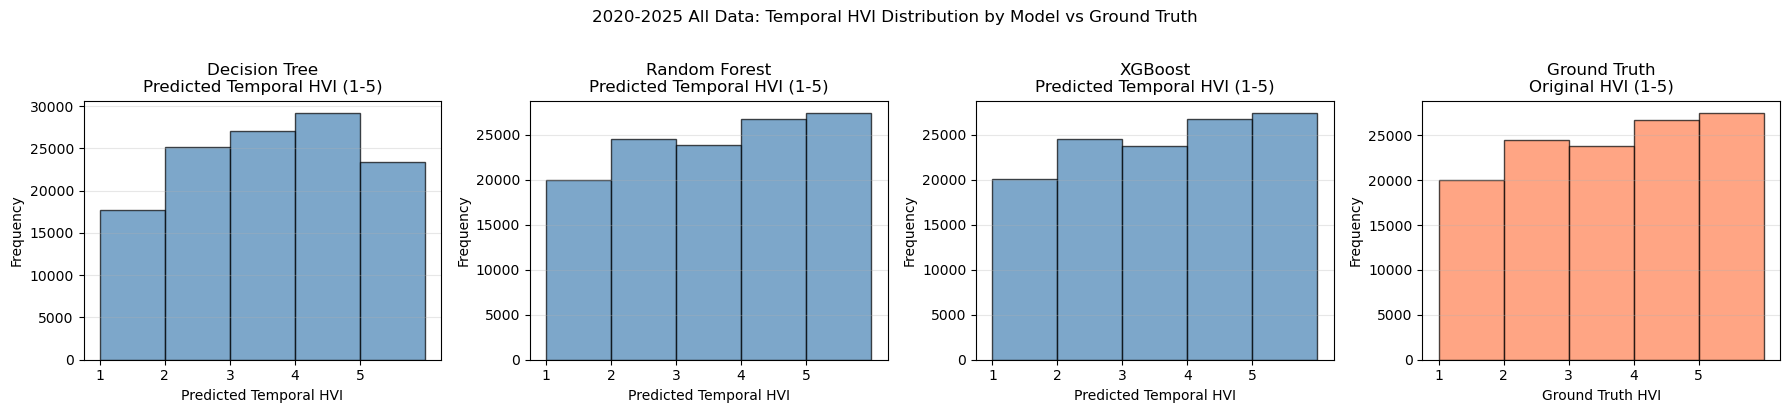

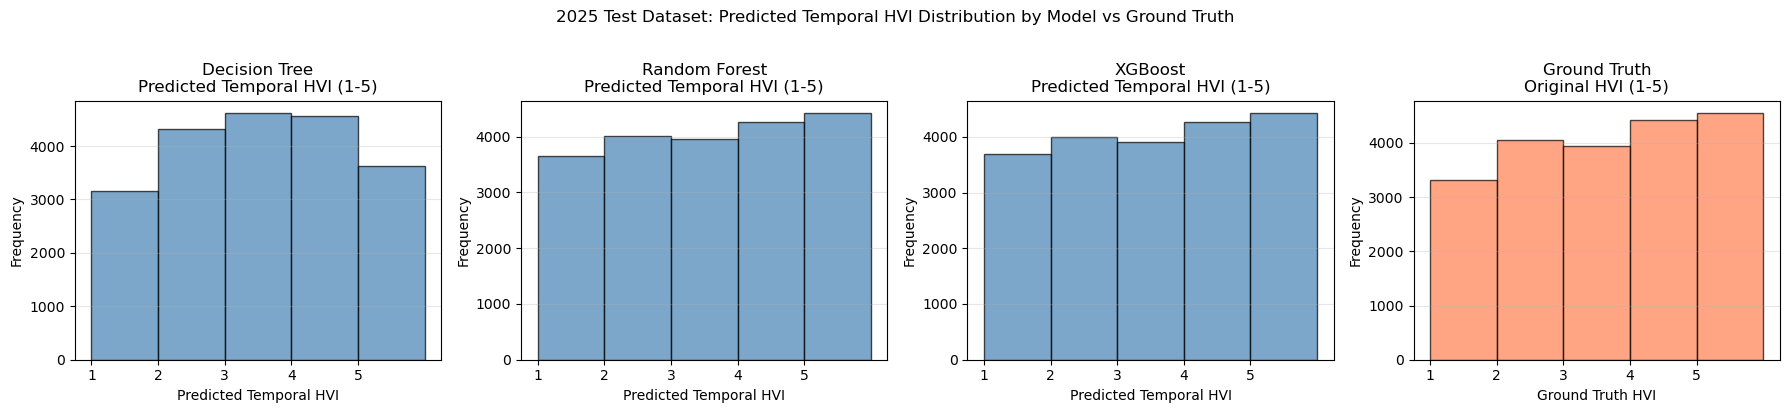

In [7]:
# ============================================================
# 5. FINAL TEMPORAL HVI PREDICTIONS (ALL MODELS)
# ============================================================
model_df['predicted_temporal_hvi_dt'] = dt.predict(X).astype(int) + 1
model_df['predicted_temporal_hvi_rf'] = rf.predict(X).astype(int) + 1
model_df['predicted_temporal_hvi_xgb'] = xgb.predict(X).astype(int) + 1

# Keep this alias for compatibility with downstream cells.
model_df['predicted_temporal_hvi'] = model_df['predicted_temporal_hvi_xgb']


# ---------------------------------------------------------------------------
# Visualization: Distribution of predicted temporal HVI for all three models + ground truth with non-temporal HVI
# for ALL DATA (2020-2025) to show overall distributional differences
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (model_col, label) in zip(
    axes[:3],
    [
        ('predicted_temporal_hvi_dt', 'Decision Tree'),
        ('predicted_temporal_hvi_rf', 'Random Forest'),
        ('predicted_temporal_hvi_xgb', 'XGBoost'),
    ]
):
    ax.hist(model_df[model_col], bins=range(1, 7), alpha=0.7, color='steelblue', edgecolor='black')
    ax.set_xlabel('Predicted Temporal HVI')
    ax.set_ylabel('Frequency')
    ax.set_xticks(range(1, 6))
    ax.set_title(f'{label}\nPredicted Temporal HVI (1-5)')
    ax.grid(True, alpha=0.3, axis='y')

# Ground truth distribution panel
ax = axes[3]
ax.hist(model_df['HVI'].clip(1, 5).round(), bins=range(1, 7), alpha=0.7, color='coral', edgecolor='black')
ax.set_xlabel('Ground Truth HVI')
ax.set_ylabel('Frequency')
ax.set_xticks(range(1, 6))
ax.set_title('Ground Truth\nOriginal HVI (1-5)')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('2020-2025 All Data: Temporal HVI Distribution by Model vs Ground Truth', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------------
# Same as above but zoomed in on 2025 data only to show distributional differences on final test set
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (model_col, label) in zip(
    axes[:3],
    [
        ('predicted_temporal_hvi_dt', 'Decision Tree'),
        ('predicted_temporal_hvi_rf', 'Random Forest'),
        ('predicted_temporal_hvi_xgb', 'XGBoost'),
    ]
):
    ax.hist(model_df[model_df['year'] == 2025][model_col], bins=range(1, 7), alpha=0.7, color='steelblue', edgecolor='black')
    ax.set_xlabel('Predicted Temporal HVI')
    ax.set_ylabel('Frequency')
    ax.set_xticks(range(1, 6))
    ax.set_title(f'{label}\nPredicted Temporal HVI (1-5)')
    ax.grid(True, alpha=0.3, axis='y')

# Ground truth distribution panel
ax = axes[3]
ax.hist(model_df[model_df['year'] == 2025]['HVI'].clip(1, 5).round(), bins=range(1, 7), alpha=0.7, color='coral', edgecolor='black')
ax.set_xlabel('Ground Truth HVI')
ax.set_ylabel('Frequency')
ax.set_xticks(range(1, 6))
ax.set_title('Ground Truth\nOriginal HVI (1-5)')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('2025 Test Dataset: Predicted Temporal HVI Distribution by Model vs Ground Truth', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()



# Mean final prediction by ZIP for each model (for comparison to original HVI later)
mean_pred_hvi = (
    model_df.groupby('zip', as_index=False)
      .agg(
          mean_temporal_hvi_dt=('predicted_temporal_hvi_dt', 'mean'),
          mean_temporal_hvi_rf=('predicted_temporal_hvi_rf', 'mean'),
          mean_temporal_hvi_xgb=('predicted_temporal_hvi_xgb', 'mean')
      )
      .sort_values('mean_temporal_hvi_xgb', ascending=False)
      .reset_index(drop=True)
)


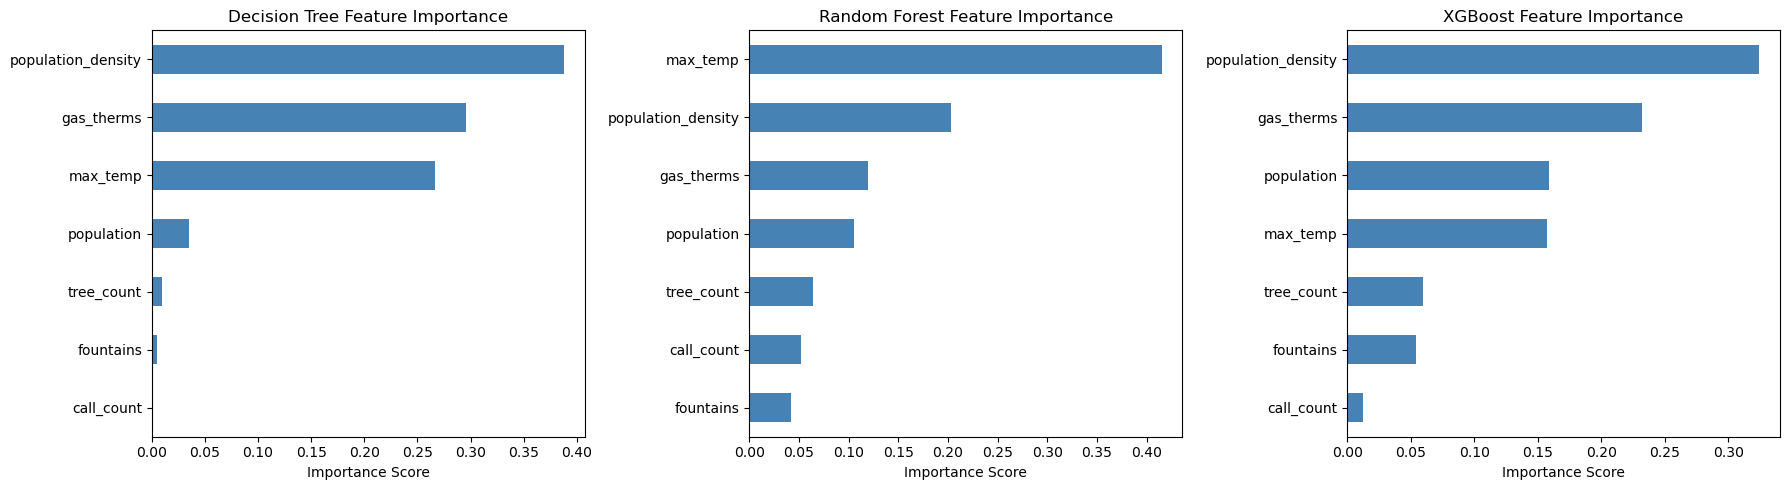

In [8]:
# ============================================================
# 6. FEATURE IMPORTANCE COMPARISON ACROSS MODELS
# to see which features are most influential for each model's predictions
# ============================================================
importance_frames = [
    ('Decision Tree', pd.Series(dt.feature_importances_, index=FEATURES)),
    ('Random Forest', pd.Series(rf.feature_importances_, index=FEATURES)),
    ('XGBoost', pd.Series(xgb.feature_importances_, index=FEATURES))
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False)
for ax, (model_name, imp) in zip(axes, importance_frames):
    imp.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{model_name} Feature Importance')
    ax.set_xlabel('Importance Score')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

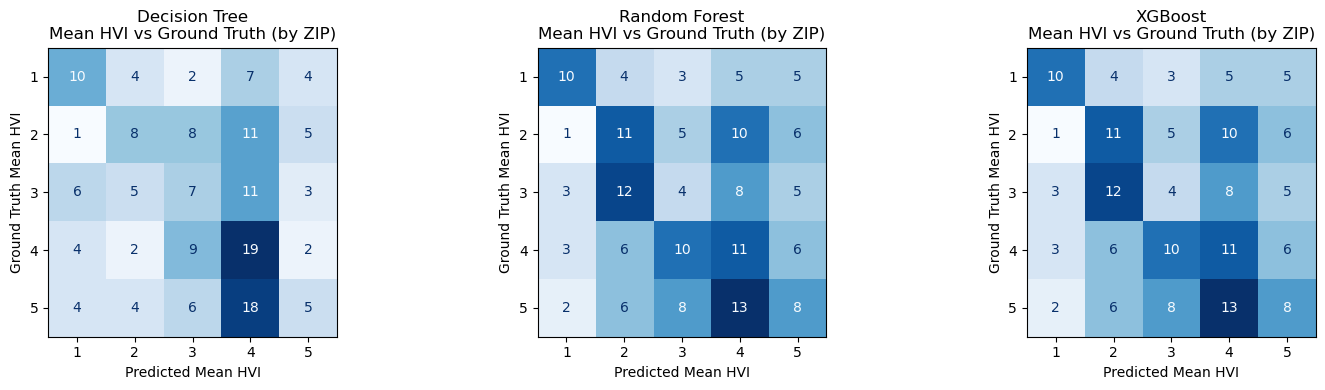

In [9]:
# ============================================================
# 7. MEAN HVI COMPARISON: MODELS vs GROUND TRUTH
# seeing how temporally averaged HVI predictions compare to mean original HVI by ZIP
# ============================================================
# Get ground truth: mean original HVI per ZIP (from 2020-2025 subset)
ground_truth_hvi = (
    model_df.groupby('zip', as_index=False)
      .agg(ground_truth_hvi=('HVI', lambda x: x.clip(1, 5).round().mean()))
)

# Merge ground truth with model predictions
comparison_df = mean_pred_hvi.merge(ground_truth_hvi, on='zip', how='left')

# Confusion matrices: each model's mean prediction vs ground truth
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model_col, label) in zip(
    axes,
    [
        ('mean_temporal_hvi_dt', 'Decision Tree'),
        ('mean_temporal_hvi_rf', 'Random Forest'),
        ('mean_temporal_hvi_xgb', 'XGBoost'),
    ]
):
    # Bin predictions and ground truth to 1-5 integer scale using ceil for model predictions
    pred_binned = round(comparison_df[model_col]).astype(int).clip(1, 5)
    truth_binned = comparison_df['ground_truth_hvi'].round().astype(int).clip(1, 5)

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        truth_binned,
        pred_binned,
        labels=[1, 2, 3, 4, 5],
        display_labels=['1', '2', '3', '4', '5'],
        ax=ax,
        cmap='Blues',
        colorbar=False
    )
    ax.set_title(f"{label}\nMean HVI vs Ground Truth (by ZIP)")
    ax.set_xlabel("Predicted Mean HVI")
    ax.set_ylabel("Ground Truth Mean HVI")

plt.tight_layout()
plt.show()



Top 3 ZIPs with highest variability in predicted HVI:
  ZIP 10460: avg std dev = 0.873
  ZIP 10451: avg std dev = 0.866
  ZIP 11435: avg std dev = 0.864


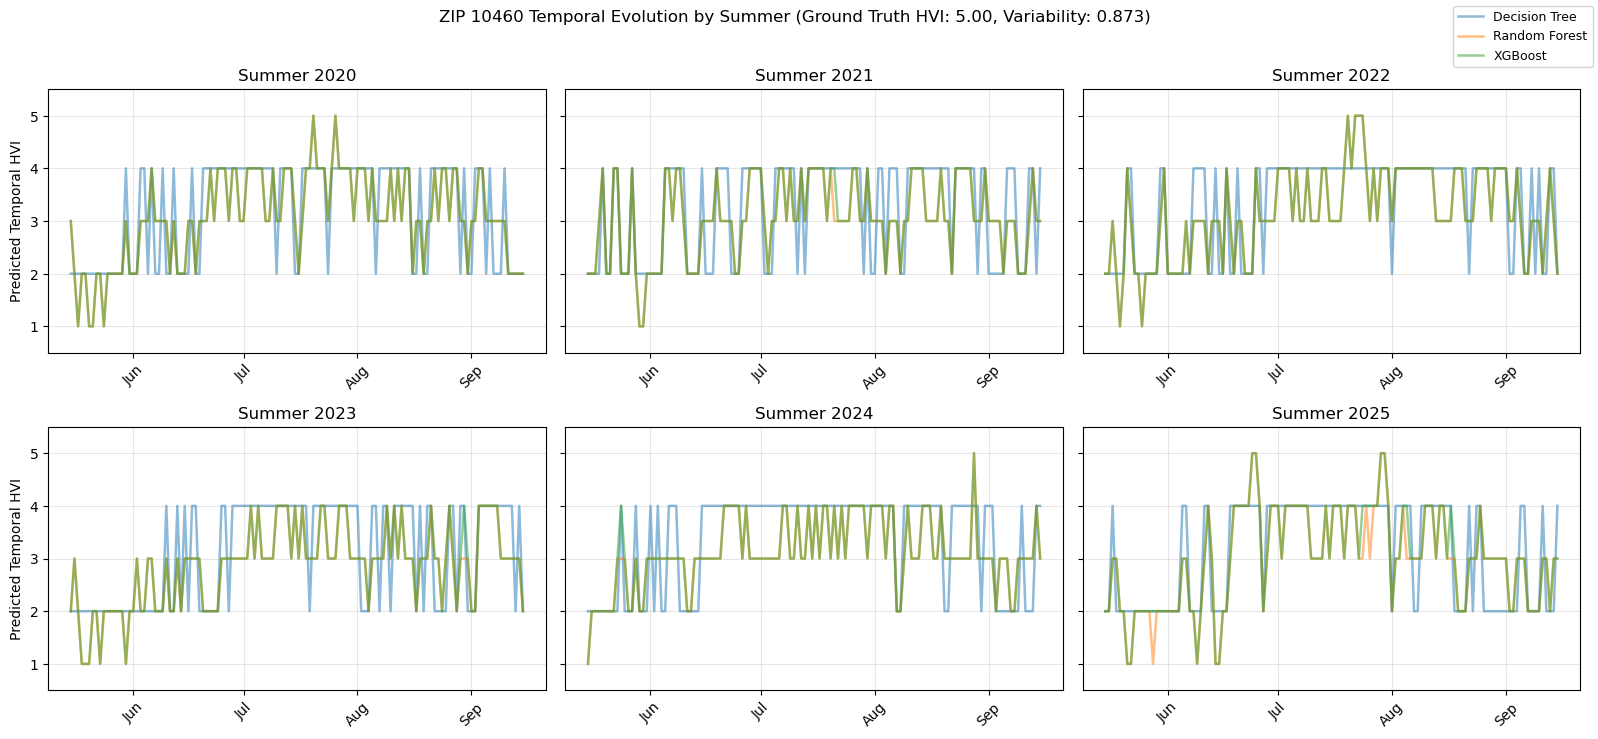

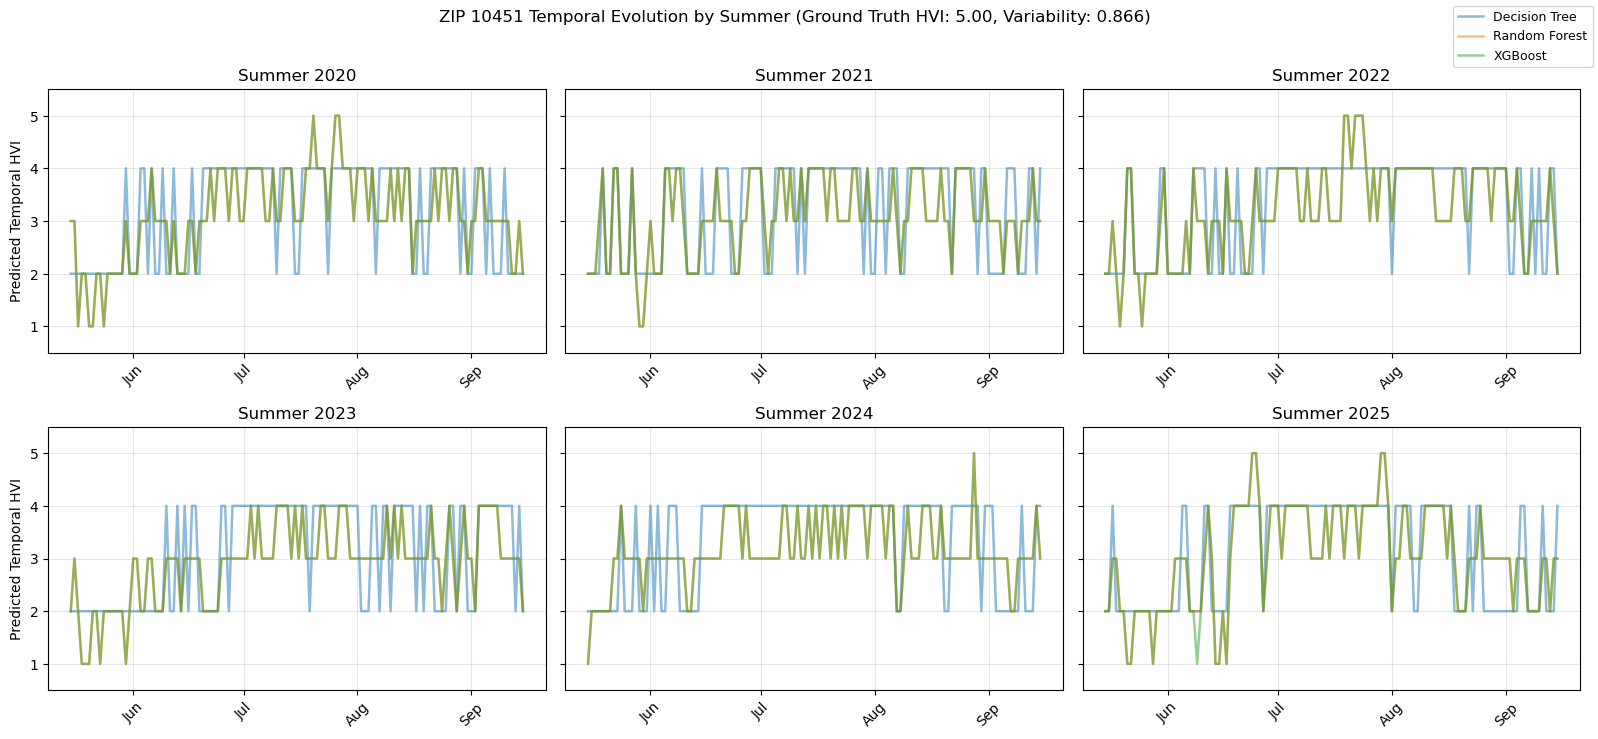

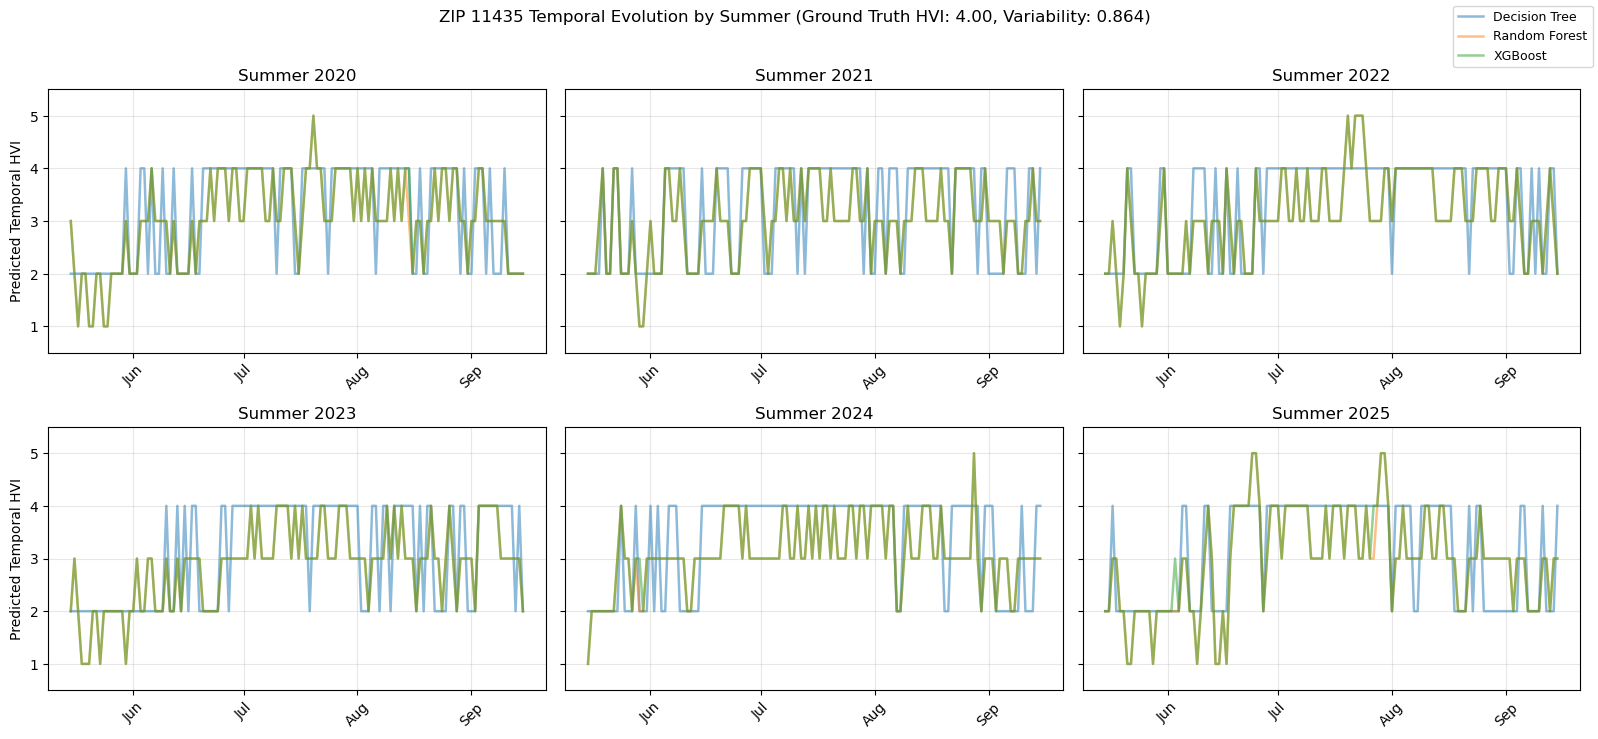

In [10]:
# ============================================================
# 8. TEMPORAL EVOLUTION: MODEL PREDICTIONS OVER TIME
# Plot top 3 ZIPs HVIs (monthly averages) by highest variability
# ============================================================
pred_cols = ['predicted_temporal_hvi_dt', 'predicted_temporal_hvi_rf', 'predicted_temporal_hvi_xgb']

# Calculate variability (std dev) of predicted HVI for each ZIP across observed dates
variability_df = (
    model_df.groupby('zip')[pred_cols]
      .std()
      .mean(axis=1)  # average variability across all three models
      .sort_values(ascending=False)
)

top_variable_zips = variability_df.head(3).index.tolist()
print(f"\nTop 3 ZIPs with highest variability in predicted HVI:")
for zip_code in top_variable_zips:
    print(f"  ZIP {zip_code}: avg std dev = {variability_df[zip_code]:.3f}")

# Restrict to selected ZIPs and prepare year for per-summer panels
summer_df = model_df[model_df['zip'].isin(top_variable_zips)].copy()
summer_df['year'] = summer_df['date'].dt.year

# Aggregate to daily means per ZIP/year/date in case there are multiple rows/day
zip_daily = (
    summer_df[['zip', 'year', 'date'] + pred_cols]
      .groupby(['zip', 'year', 'date'], as_index=False)
      .mean()
)

# Ground-truth lookup for titles (computed in prior comparison cell)
gt_lookup = comparison_df.set_index('zip')['ground_truth_hvi'].to_dict()

# One figure per ZIP, with one subplot per summer year (typically 2020-2025 => 6 subplots)
for zip_code in top_variable_zips:
    zip_yearly = zip_daily[zip_daily['zip'] == zip_code].copy()
    years = sorted(zip_yearly['year'].unique())

    n_cols = 3
    n_rows = int(np.ceil(len(years) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.6 * n_rows), sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for i, year in enumerate(years):
        ax = axes[i]
        yearly = zip_yearly[zip_yearly['year'] == year].sort_values('date')

        ax.plot(yearly['date'], yearly['predicted_temporal_hvi_dt'], linewidth=1.8, alpha = 0.5,label='Decision Tree')
        ax.plot(yearly['date'], yearly['predicted_temporal_hvi_rf'], linewidth=1.8, alpha = 0.5, label='Random Forest')
        ax.plot(yearly['date'], yearly['predicted_temporal_hvi_xgb'], linewidth=1.8, alpha = 0.5, label='XGBoost')

        ax.set_title(f'Summer {year}')
        ax.set_ylim(0.5, 5.5)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        ax.tick_params(axis='x', rotation=45)

        if i % n_cols == 0:
            ax.set_ylabel('Predicted Temporal HVI')

    # Turn off any unused subplot slots
    for ax in axes[len(years):]:
        ax.axis('off')

    gt_hvi = gt_lookup.get(zip_code, np.nan)
    gt_str = f"{gt_hvi:.2f}" if pd.notna(gt_hvi) else "N/A"
    fig.suptitle(
        f"ZIP {zip_code} Temporal Evolution by Summer "
        f"(Ground Truth HVI: {gt_str}, Variability: {variability_df[zip_code]:.3f})",
        y=1.02,
        fontsize=12
    )

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize=9)
    fig.tight_layout()
    plt.show()

In [11]:
# ============================================================
# 9. MODEL AGREEMENT: DO ALL THREE MODELS AGREE?
# ============================================================
# Compare pairwise disagreement between models
comparison_df['dt_rf_diff'] = (comparison_df['mean_temporal_hvi_dt'] - comparison_df['mean_temporal_hvi_rf']).abs()
comparison_df['dt_xgb_diff'] = (comparison_df['mean_temporal_hvi_dt'] - comparison_df['mean_temporal_hvi_xgb']).abs()
comparison_df['rf_xgb_diff'] = (comparison_df['mean_temporal_hvi_rf'] - comparison_df['mean_temporal_hvi_xgb']).abs()

print("\n=== Model Agreement Analysis ===")
print(f"Mean absolute difference (DT vs RF): {comparison_df['dt_rf_diff'].mean():.3f}")
print(f"Mean absolute difference (DT vs XGB): {comparison_df['dt_xgb_diff'].mean():.3f}")
print(f"Mean absolute difference (RF vs XGB): {comparison_df['rf_xgb_diff'].mean():.3f}")

# ZIPs with highest disagreement
comparison_df['max_disagreement'] = comparison_df[['dt_rf_diff', 'dt_xgb_diff', 'rf_xgb_diff']].max(axis=1)
print("\nZIPs with highest model disagreement:")
print(comparison_df.nlargest(5, 'max_disagreement')[['zip', 'ground_truth_hvi', 'mean_temporal_hvi_dt', 'mean_temporal_hvi_rf', 'mean_temporal_hvi_xgb', 'max_disagreement']])



=== Model Agreement Analysis ===
Mean absolute difference (DT vs RF): 0.173
Mean absolute difference (DT vs XGB): 0.172
Mean absolute difference (RF vs XGB): 0.002

ZIPs with highest model disagreement:
       zip  ground_truth_hvi  mean_temporal_hvi_dt  mean_temporal_hvi_rf  \
27   10011               1.0              3.733513              4.623149   
98   10469               5.0              3.612382              2.795424   
20   10456               5.0              4.016151              4.722746   
123  11417               3.0              2.612382              1.951548   
33   11213               5.0              3.733513              4.394347   

     mean_temporal_hvi_xgb  max_disagreement  
27                4.619112          0.889637  
98                2.795424          0.816958  
20                4.720054          0.706595  
123               1.954240          0.660834  
33                4.390310          0.660834  


## Section 2 Overview: LSTM & Why it Helps our Project

Project's problem: the existing NYC Heat Vulnerability Index (HVI) is valuable but static. By "static," we mean that the HVI identifies which neighborhoods are generally more vulnerable to heat, but it does not update day by day as conditions change. In practice, this means that an area’s official vulnerability score may not fully capture short-term changes in temperature, complaints, infrastructure stress, or other daily signals.

Project's model: an ML feature called Long Short Term Memory to move from a static HVI framework toward a dynamic prediction tool: instead of assigning each ZIP code a fixed vulnerability score, the model predicts a daily temporal HVI category using recent ZIP-code-level data.



## Making LSTM Model and Tuning Hyperparameters
**High-level explanation:** Here is our LSTM model... at least the first attempt! Instead of asking only what a ZIP code’s vulnerability looks like on 1 isolated day, the model asks whether recent patterns over the previous several days can help predict the current day’s temporal HVI category. This matters because the project’s main problem, and subequent contribution to the literature, is that the official HVI is useful but static. This LSTM addresses this limitation by learning from sequences of ZIP-code-level observations. In other words, we use recent historical signals — including heat complaints, temperature, tree coverage, population density, population, water fountain access, and gas usage — to classify each ZIP code’s current temporal heat vulnerability level from 1 to 5. The code also evaluates how well the LSTM performs using a held-out test set, classification metrics, a confusion matrix, and training history plots.

**Technical explantation:**
1. Code first prepares the dataset by copying model_df, converting the date column into a datetime format, converting ZIP codes into strings, and recoding the target variable temporal_hvi_target from a 1–5 scale into a 0–4 scale, which is required for TensorFlow’s sparse categorical classification loss.
2. Then it removes rows with missing values in the selected feature columns or target variable and sorts the data by ZIP code and date.
3. The code creates a temporal train-validation-test split, using observations through 2023 for training, 2024 for validation, and 2025 for testing; this is more rigorous than a random split because it evaluates whether the model can generalize to later time periods. The feature variables are standardized using StandardScaler, with the scaler fit only on the training set to avoid data leakage.
4. The key LSTM-specific step is the create_sequences() function, which groups the data by ZIP code and transforms the flat dataset into three-dimensional input tensors. Each input sequence has shape 7 × 7, meaning seven prior ZIP-code-day observations and seven features per day.
5. The model then uses an LSTM layer with 64 units, dropout regularization, a dense hidden layer, and a five-unit softmax output layer to predict one of five temporal HVI classes.
7. It is trained with sparse categorical cross-entropy loss and Adam optimization, while early stopping monitors validation loss and restores the best-performing model weights. Finally, the code predicts temporal HVI categories on the test set, computes accuracy, macro F1, and weighted F1, and visualizes performance through a confusion matrix and training/validation accuracy and loss curves.


This chunk checks whether the LSTM model is stable by testing several versions of it with different settings. Rather than depending on one model setup, it compares performance across different lookback windows, LSTM unit sizes, dropout rates, and batch sizes. This is important because our project’s main claim is that heat vulnerability is temporal: recent conditions may build on one another over several days. When we compare 3-day, 7-day, and 14-day windows, the model tests whether giving the LSTM more recent history improves its ability to classify ZIP-code-level heat vulnerability. The experiment table also makes the final model choice more defensible because it shows that the selected LSTM was chosen through systematic comparison rather than trial and error. Bianca will LOVE this!

In [12]:
# ============================================================
# 1. PREPARE DATA FOR LSTM
# ============================================================
TARGET = "temporal_hvi_target"

# LSTM DATAFRAME FORMATTING
print("model_df shape:", model_df.shape)
print("FEATURES:", FEATURES)
print("Columns:", model_df.columns.tolist())

lstm_df = model_df.copy()

# Make sure date and ZIP code are formatted correctly
lstm_df["date"] = pd.to_datetime(lstm_df["date"])
lstm_df["zip"] = lstm_df["zip"].astype(str)

# Convert target from 1–5 scale to 0–4 scale for sparse categorical cross-entropy
lstm_df["target_lstm"] = lstm_df[TARGET].astype(int) - 1

# Drop missing values in features, target, date, or ZIP code
lstm_df = lstm_df.dropna(subset=FEATURES + ["target_lstm", "date", "zip"]).copy()

# Sort by ZIP code and date so sequences are chronologically ordered
lstm_df = lstm_df.sort_values(["zip", "date"]).reset_index(drop=True)
lstm_df["year"] = lstm_df["date"].dt.year



# TEMPORAL TRAIN / VALIDATION / TEST DATA SPLITTING
# Train/Validation (90-10): 2020–2024 | Test: 2025 (same configuration as other models, based on LSTM dataset this time)
# make datasets used to experiment with hyperparameter tuning
experiment_df = lstm_df.dropna(
    subset=FEATURES + [TARGET, "date", "zip"]
).copy()


# TEMPORAL TRAIN / VALIDATION / TEST DATA SPLITTING
# Train: 2020–2023 | Validation: 2024 (full year) | Test: 2025
train_base = experiment_df[experiment_df['date'] < '2024-01-01'].copy()

val_base = experiment_df[experiment_df['year'] == 2024].copy()

test_base = experiment_df[experiment_df['year'] == 2025].copy()


# FIT LSTM SCALER 
scaler_exp = StandardScaler()
train_base[FEATURES] = scaler_exp.fit_transform(train_base[FEATURES])
val_base[FEATURES] = scaler_exp.transform(val_base[FEATURES])
test_base[FEATURES] = scaler_exp.transform(test_base[FEATURES])

model_df shape: (122595, 19)
FEATURES: ['call_count', 'max_temp', 'tree_count', 'population_density', 'population', 'fountains', 'gas_therms']
Columns: ['Unnamed: 0', 'zip', 'date', 'call_count', 'HVI', 'fountains', 'gas_therms', 'tree_count', 'population_density', 'population', 'max_temp', 'year', 'month', 'temporal_risk_signal', 'temporal_hvi_target', 'predicted_temporal_hvi_dt', 'predicted_temporal_hvi_rf', 'predicted_temporal_hvi_xgb', 'predicted_temporal_hvi']


In [ ]:
# ============================================================
# 2. FUNCTIONS FOR BUILDING LSTM AND TUNING HYPERPARAMETERS
# ============================================================
# make sequences of hyperparameters to iterate through for tuning
def create_sequences(df, features, target_col, lookback):
    X_sequences = []
    y_sequences = []

    df = df.sort_values(["zip", "date"]).copy()

    for zip_code, group in df.groupby("zip"):
        group = group.sort_values("date").copy()

        if len(group) <= lookback:
            continue

        X_values = group[features].values
        y_values = group[target_col].values

        for i in range(lookback, len(group)):
            # Previous lookback days predict the current day's temporal HVI class
            X_sequences.append(X_values[i - lookback:i])
            y_sequences.append(y_values[i])

    return np.array(X_sequences), np.array(y_sequences)


@tf.keras.utils.register_keras_serializable(package="Custom")
class WarmupConstantSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_lr, warmup_steps):
        super().__init__()
        self.initial_lr = float(initial_lr)
        self.warmup_steps = int(warmup_steps)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_steps = tf.cast(self.warmup_steps, tf.float32)
        return self.initial_lr * tf.minimum(1.0, step / tf.maximum(warmup_steps, 1.0))

    def get_config(self):
        return {"initial_lr": float(self.initial_lr), "warmup_steps": int(self.warmup_steps)}

    @classmethod
    def from_config(cls, config):
        return cls(**config)


@tf.keras.utils.register_keras_serializable(package="Custom")
class WarmupCosineSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_lr, warmup_steps, total_steps):
        super().__init__()
        self.initial_lr = float(initial_lr)
        self.warmup_steps = int(warmup_steps)
        self.total_steps = int(total_steps)
        decay_steps = max(self.total_steps - self.warmup_steps, 1)
        self.cosine = tf.keras.optimizers.schedules.CosineDecay(self.initial_lr, decay_steps)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_steps = tf.cast(self.warmup_steps, tf.float32)
        warmup_lr = self.initial_lr * tf.minimum(1.0, step / tf.maximum(warmup_steps, 1.0))
        decay_step = tf.maximum(step - warmup_steps, 0.0)
        cosine_lr = self.cosine(decay_step)
        return tf.where(step < warmup_steps, warmup_lr, cosine_lr)

    def get_config(self):
        return {
            "initial_lr": float(self.initial_lr),
            "warmup_steps": int(self.warmup_steps),
            "total_steps": int(self.total_steps),
        }

    @classmethod
    def from_config(cls, config):
        return cls(**config)


# Helper: learning rate schedule with optional warmup
def make_lr_schedule(initial_lr, warmup_steps=0, total_steps=None, schedule="constant"):
    if warmup_steps is None or warmup_steps <= 0:
        warmup_steps = 0

    if schedule == "constant":
        if warmup_steps == 0:
            return float(initial_lr)
        return WarmupConstantSchedule(initial_lr, warmup_steps)

    if schedule == "cosine":
        if total_steps is None:
            raise ValueError("total_steps required for cosine schedule")
        if warmup_steps == 0:
            return tf.keras.optimizers.schedules.CosineDecay(initial_lr, max(total_steps, 1))
        return WarmupCosineSchedule(initial_lr, warmup_steps, total_steps)

    raise ValueError("Unknown schedule type")


In [14]:
# ============================================================
# 3. HYPERPARAMETER TUNING LOOP
# ============================================================
np.random.seed(123)
tf.random.set_seed(123)


# Reasonable tuning grid (kept moderate) - expands hyperparameters to tune
experiments = [
    # lookback, units, dropout, batch_size, lr, lr_schedule, warmup_steps, weight_decay, momentum, init, epochs
    {"lookback": 3,  "units": 32,  "dropout": 0.2, "batch_size": 32,  "lr": 3e-4, "lr_schedule": "constant", "warmup": 0,   "weight_decay": 0.0,    "momentum": 0.0, "init": "glorot_uniform", "epochs": 20},
    {"lookback": 7,  "units": 64,  "dropout": 0.3, "batch_size": 64,  "lr": 3e-4, "lr_schedule": "cosine",   "warmup": 50,  "weight_decay": 1e-6,   "momentum": 0.0, "init": "glorot_uniform", "epochs": 25},
    {"lookback": 14, "units": 64,  "dropout": 0.3, "batch_size": 64,  "lr": 1e-4, "lr_schedule": "cosine",   "warmup": 100, "weight_decay": 1e-6,   "momentum": 0.0, "init": "he_normal",      "epochs": 25},
    {"lookback": 7,  "units": 128, "dropout": 0.5, "batch_size": 32,  "lr": 5e-4, "lr_schedule": "constant", "warmup": 0,   "weight_decay": 0.0,    "momentum": 0.0, "init": "he_normal",      "epochs": 20},
    {"lookback": 7,  "units": 64,  "dropout": 0.3, "batch_size": 128, "lr": 1e-3, "lr_schedule": "constant", "warmup": 0,   "weight_decay": 1e-5,   "momentum": 0.9, "init": "glorot_uniform", "epochs": 15},
    {"lookback": 3,  "units": 64,  "dropout": 0.2, "batch_size": 64,  "lr": 3e-4, "lr_schedule": "cosine",   "warmup": 20,  "weight_decay": 0.0,    "momentum": 0.9, "init": "glorot_uniform", "epochs": 20},
    {"lookback": 14, "units": 128, "dropout": 0.3, "batch_size": 64,  "lr": 3e-4, "lr_schedule": "cosine",   "warmup": 100, "weight_decay": 1e-5,   "momentum": 0.9, "init": "he_normal",      "epochs": 20},
    {"lookback": 7,  "units": 256, "dropout": 0.3, "batch_size": 64,  "lr": 3e-4, "lr_schedule": "cosine", "warmup": 50,    "weight_decay": 1e-6,   "momentum": 0.0, "init": "he_normal", "epochs": 20},
    {"lookback": 7,  "units": 128, "dropout": 0.3, "batch_size": 64,  "lr": 1e-3, "lr_schedule": "constant", "warmup": 0,   "weight_decay": 0.0,    "momentum": 0.0, "init": "he_normal",      "epochs": 15}
]

# experiments unused because they were too computationally expensive
#{"lookback": 7,  "units": 64,  "dropout": 0.1, "batch_size": 32,  "lr": 5e-5, "lr_schedule": "cosine", "warmup": 20,  "weight_decay": 1e-6, "momentum": 0.0, "init": "glorot_uniform", "epochs": 25},
#    {"lookback": 14, "units": 64,  "dropout": 0.2, "batch_size": 16,  "lr": 1e-4, "lr_schedule": "constant", "warmup": 0,   "weight_decay": 0.0,    "momentum": 0.9, "init": "glorot_uniform", "epochs": 25},

results = []
histories = []  # store training histories for optional plotting
start_all = time.time()

for i, config in enumerate(experiments, start=1):
    print(f"\nRunning experiment {i}/{len(experiments)}: {config}")
    t0 = time.time()

    lookback = config['lookback']
    units = config['units']
    dropout = config['dropout']
    batch_size = config['batch_size']
    base_lr = config['lr']
    lr_schedule_type = config['lr_schedule']
    warmup_steps = config['warmup']
    weight_decay = config['weight_decay']
    momentum = config['momentum']
    init_name = config['init']
    epochs = config.get('epochs', 25)

    # make data sequences
    X_train_exp, y_train_exp = create_sequences(train_base, FEATURES, 'target_lstm', lookback)
    X_val_exp, y_val_exp = create_sequences(val_base, FEATURES, 'target_lstm', lookback)
    X_test_exp, y_test_exp = create_sequences(test_base, FEATURES, 'target_lstm', lookback)

    if X_train_exp.shape[0] == 0 or X_val_exp.shape[0] == 0 or X_test_exp.shape[0] == 0:
        print(f"Skipping experiment {i}: one sequence set has 0 rows.")
        continue

    # scale LR by batch size (linear scaling rule w.r.t. reference 64)
    lr = base_lr * (batch_size / 64)

    # make lr schedule
    total_steps = int(epochs * np.ceil(X_train_exp.shape[0] / batch_size))
    lr_sched = make_lr_schedule(lr, warmup_steps=warmup_steps, total_steps=total_steps, schedule=lr_schedule_type)

    # get initializer
    initializer = tf.keras.initializers.get(init_name)

    # build model (with explicit initializers)
    model = Sequential([
        Input(shape=(lookback, len(FEATURES))),
        LSTM(units, kernel_initializer=initializer),
        Dropout(dropout),
        Dense(32, activation='relu', kernel_initializer=initializer),
        Dropout(0.20),
        Dense(5, activation='softmax', kernel_initializer=initializer)
    ])

    # choose optimizer: prefer AdamW if available for weight decay, else Adam with no explicit WD
    try:
        Optim = tf.keras.optimizers.experimental.AdamW
        optimizer = Optim(learning_rate=lr_sched if callable(lr_sched) else lr_sched, weight_decay=weight_decay, beta_1=momentum)
    except Exception:
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr_sched if callable(lr_sched) else lr_sched)

    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history_exp = model.fit(X_train_exp, y_train_exp, validation_data=(X_val_exp, y_val_exp), epochs=epochs, batch_size=batch_size, callbacks=[early_stop], verbose=0)

    # evaluate
    val_probs = model.predict(X_val_exp, verbose=0)
    val_preds = np.argmax(val_probs, axis=1)
    test_probs = model.predict(X_test_exp, verbose=0)
    test_preds = np.argmax(test_probs, axis=1)

    elapsed = time.time() - t0
    print(f"Experiment {i} finished in {elapsed:.1f}s | trained epochs: {len(history_exp.history['loss'])}")

    results.append({
        'Experiment': i,
        'Lookback': lookback,
        'Units': units,
        'Dropout': dropout,
        'Batch Size': batch_size,
        'LR (scaled)': lr,
        'LR Schedule': lr_schedule_type,
        'Warmup steps': warmup_steps,
        'Weight Decay': weight_decay,
        'Momentum': momentum,
        'Init': init_name,
        'Val Acc': accuracy_score(y_val_exp, val_preds),
        'Val Macro F1': f1_score(y_val_exp, val_preds, average='macro', zero_division=0),
        'Test Acc': accuracy_score(y_test_exp, test_preds),
        'Test Macro F1': f1_score(y_test_exp, test_preds, average='macro', zero_division=0),
        'Test Weighted F1': f1_score(y_test_exp, test_preds, average='weighted', zero_division=0),
        'Test MAE': mean_absolute_error(y_test_exp + 1, test_preds + 1),
        'Epochs Trained': len(history_exp.history['loss'])
        })
    histories.append(history_exp.history)

# Summary dataframe
hyperparameters = pd.DataFrame(results).round(4)

# histories list for plotting later
sweep_histories = histories

# Save hyperparameters to CSV in case of later analysis
hyperparameters.to_csv('lstm_hyperparameter_experiments.csv', index=False)



Running experiment 1/9: {'lookback': 3, 'units': 32, 'dropout': 0.2, 'batch_size': 32, 'lr': 0.0003, 'lr_schedule': 'constant', 'warmup': 0, 'weight_decay': 0.0, 'momentum': 0.0, 'init': 'glorot_uniform', 'epochs': 20}


2026-05-04 21:42:31.879963: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-05-04 21:42:31.880199: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-04 21:42:31.880222: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-05-04 21:42:31.880245: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-04 21:42:31.880262: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-05-04 21:42:32.586603: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Experiment 1 finished in 555.3s | trained epochs: 20

Running experiment 2/9: {'lookback': 7, 'units': 64, 'dropout': 0.3, 'batch_size': 64, 'lr': 0.0003, 'lr_schedule': 'cosine', 'warmup': 50, 'weight_decay': 1e-06, 'momentum': 0.0, 'init': 'glorot_uniform', 'epochs': 25}
Experiment 2 finished in 225.4s | trained epochs: 15

Running experiment 3/9: {'lookback': 14, 'units': 64, 'dropout': 0.3, 'batch_size': 64, 'lr': 0.0001, 'lr_schedule': 'cosine', 'warmup': 100, 'weight_decay': 1e-06, 'momentum': 0.0, 'init': 'he_normal', 'epochs': 25}
Experiment 3 finished in 393.3s | trained epochs: 25

Running experiment 4/9: {'lookback': 7, 'units': 128, 'dropout': 0.5, 'batch_size': 32, 'lr': 0.0005, 'lr_schedule': 'constant', 'warmup': 0, 'weight_decay': 0.0, 'momentum': 0.0, 'init': 'he_normal', 'epochs': 20}
Experiment 4 finished in 238.5s | trained epochs: 8

Running experiment 5/9: {'lookback': 7, 'units': 64, 'dropout': 0.3, 'batch_size': 128, 'lr': 0.001, 'lr_schedule': 'constant', 'warm

In [ ]:
# ============================================================
# 4. HYPERPARAMETER TABULAR SUMMARIES
# ============================================================
metric_cols = [
    'Val Acc', 'Val Macro F1', 'Test Acc', 'Test Macro F1', 'Test Weighted F1', 'Test MAE', 'Epochs Trained'
]
metric_cols = [c for c in metric_cols if c in hyperparameters.columns]

hyperparam_cols = [
    'Lookback', 'Units', 'Dropout', 'Batch Size', 'LR (scaled)',
    'LR Schedule', 'Warmup steps', 'Weight Decay', 'Momentum', 'Init'
]
hyperparam_cols = [c for c in hyperparam_cols if c in hyperparameters.columns]

hp_summary_tables = {}
best_levels = []

for hp in hyperparam_cols:
    summary = (
        hyperparameters
        .groupby(hp, dropna=False)[metric_cols]
        .agg(['mean', 'count'])
        .reset_index()
    )

    # Flatten multi-index columns for easier reading/export.
    summary.columns = [
        hp if col == (hp, '') else f"{col[0]} ({col[1]})"
        for col in summary.columns
    ]

    # Sort by strongest validation macro F1 if available.
    if 'Val Macro F1 (mean)' in summary.columns:
        summary = summary.sort_values('Val Macro F1 (mean)', ascending=False)

    hp_summary_tables[hp] = summary

    # Track best level by validation macro F1 and test macro F1.
    best_by_val = summary.iloc[0][hp]
    best_val_f1 = summary.iloc[0].get('Val Macro F1 (mean)', np.nan)

    if 'Test Macro F1 (mean)' in summary.columns:
        idx_best_test = summary['Test Macro F1 (mean)'].idxmax()
        best_by_test = summary.loc[idx_best_test, hp]
        best_test_f1 = summary.loc[idx_best_test, 'Test Macro F1 (mean)']
    else:
        best_by_test = np.nan
        best_test_f1 = np.nan

    best_levels.append({
        'Hyperparameter': hp,
        'Best level (Val Macro F1)': best_by_val,
        'Val Macro F1 at best level': best_val_f1,
        'Best level (Test Macro F1)': best_by_test,
        'Test Macro F1 at best level': best_test_f1,
    })

best_levels_df = pd.DataFrame(best_levels)

print("=== Best Hyperparameter Levels (by aggregated means) ===")
display(best_levels_df)

print("\n=== Per-hyperparameter summary tables ===")
for hp, tbl in hp_summary_tables.items():
    print(f"\n--- {hp} ---")
    display(tbl)


=== Best Hyperparameter Levels (by aggregated means) ===


,Hyperparameter,Best level (Val Macro F1),Val Macro F1 at best level,Best level (Test Macro F1),Test Macro F1 at best level
0,Lookback,14.0,0.755100,14,0.691150
1,Units,32.0,0.755200,32,0.687800
2,Dropout,0.2,0.753600,0.5,0.691000
3,Batch Size,32.0,0.748900,32,0.689400
4,LR (scaled),0.0001,0.753550,0.0002,0.691000
5,LR Schedule,cosine,0.750580,cosine,0.688320
6,Warmup steps,100.0,0.755100,100,0.691150
7,Weight Decay,0.0,0.747422,0.0,0.684900
8,Momentum,0.9,0.751100,0.9,0.684967
9,Init,glorot_uniform,0.749000,he_normal,0.685740



=== Per-hyperparameter summary tables ===

--- Lookback ---


,Lookback,Val Acc (mean),Val Acc (count),Val Macro F1 (mean),Val Macro F1 (count),Test Acc (mean),Test Acc (count),Test Macro F1 (mean),Test Macro F1 (count),Test Weighted F1 (mean),Test Weighted F1 (count),Test MAE (mean),Test MAE (count),Epochs Trained (mean),Epochs Trained (count)
2,14,0.75925,2,0.75510,2,0.69055,2,0.69115,2,0.69260,2,0.32635,2,21.5,2
0,3,0.75540,2,0.75360,2,0.68785,2,0.68815,2,0.68980,2,0.33500,2,20.0,2
1,7,0.74630,5,0.74188,5,0.68256,5,0.68110,5,0.68248,5,0.34066,5,9.4,5



--- Units ---


,Units,Val Acc (mean),Val Acc (count),Val Macro F1 (mean),Val Macro F1 (count),Test Acc (mean),Test Acc (count),Test Macro F1 (mean),Test Macro F1 (count),Test Weighted F1 (mean),Test Weighted F1 (count),Test MAE (mean),Test MAE (count),Epochs Trained (mean),Epochs Trained (count)
0,32,0.757000,1,0.755200,1,0.687600,1,0.687800,1,0.6895,1,0.335900,1,20.0,1
1,64,0.751225,4,0.748175,4,0.684150,4,0.684200,4,0.6854,4,0.337500,4,16.5,4
3,256,0.747900,1,0.744900,1,0.685100,1,0.685000,1,0.6866,1,0.338500,1,11.0,1
2,128,0.750333,3,0.744667,3,0.686767,3,0.684833,3,0.6865,3,0.333867,3,11.0,3



--- Dropout ---


,Dropout,Val Acc (mean),Val Acc (count),Val Macro F1 (mean),Val Macro F1 (count),Test Acc (mean),Test Acc (count),Test Macro F1 (mean),Test Macro F1 (count),Test Weighted F1 (mean),Test Weighted F1 (count),Test MAE (mean),Test MAE (count),Epochs Trained (mean),Epochs Trained (count)
0,0.2,0.755400,2,0.753600,2,0.687850,2,0.68815,2,0.689800,2,0.335000,2,20.000000,2
1,0.3,0.750467,6,0.746167,6,0.683683,6,0.68280,6,0.684217,6,0.337917,6,13.666667,6
2,0.5,0.747200,1,0.742600,1,0.691800,1,0.69100,1,0.692300,1,0.328500,1,8.000000,1



--- Batch Size ---


,Batch Size,Val Acc (mean),Val Acc (count),Val Macro F1 (mean),Val Macro F1 (count),Test Acc (mean),Test Acc (count),Test Macro F1 (mean),Test Macro F1 (count),Test Weighted F1 (mean),Test Weighted F1 (count),Test MAE (mean),Test MAE (count),Epochs Trained (mean),Epochs Trained (count)
0,32,0.75210,2,0.748900,2,0.68970,2,0.689400,2,0.6909,2,0.332200,2,14.0,2
1,64,0.75175,6,0.747667,6,0.68595,6,0.685333,6,0.6869,6,0.335367,6,16.0,6
2,128,0.74610,1,0.743000,1,0.67450,1,0.673300,1,0.6740,1,0.349400,1,6.0,1



--- LR (scaled) ---


,LR (scaled),Val Acc (mean),Val Acc (count),Val Macro F1 (mean),Val Macro F1 (count),Test Acc (mean),Test Acc (count),Test Macro F1 (mean),Test Macro F1 (count),Test Weighted F1 (mean),Test Weighted F1 (count),Test MAE (mean),Test MAE (count),Epochs Trained (mean),Epochs Trained (count)
0,0.0001,0.7565,2,0.75355,2,0.687900,2,0.6885,2,0.6900,2,0.33285,2,22.5,2
2,0.0003,0.7533,4,0.75025,4,0.687975,4,0.6881,4,0.6896,4,0.33305,4,16.0,4
4,0.0020,0.7461,1,0.74300,1,0.674500,1,0.6733,1,0.6740,1,0.34940,1,6.0,1
1,0.0002,0.7472,1,0.74260,1,0.691800,1,0.6910,1,0.6923,1,0.32850,1,8.0,1
3,0.0010,0.7413,1,0.73310,1,0.675600,1,0.6704,1,0.6725,1,0.35020,1,7.0,1



--- LR Schedule ---


,LR Schedule,Val Acc (mean),Val Acc (count),Val Macro F1 (mean),Val Macro F1 (count),Test Acc (mean),Test Acc (count),Test Macro F1 (mean),Test Macro F1 (count),Test Weighted F1 (mean),Test Weighted F1 (count),Test MAE (mean),Test MAE (count),Epochs Trained (mean),Epochs Trained (count)
1,cosine,0.75384,5,0.750580,5,0.688020,5,0.688320,5,0.689780,5,0.3324,5,17.80,5
0,constant,0.74790,4,0.743475,4,0.682375,4,0.680625,4,0.682075,4,0.3410,4,10.25,4



--- Warmup steps ---


,Warmup steps,Val Acc (mean),Val Acc (count),Val Macro F1 (mean),Val Macro F1 (count),Test Acc (mean),Test Acc (count),Test Macro F1 (mean),Test Macro F1 (count),Test Weighted F1 (mean),Test Weighted F1 (count),Test MAE (mean),Test MAE (count),Epochs Trained (mean),Epochs Trained (count)
3,100,0.75925,2,0.755100,2,0.690550,2,0.691150,2,0.692600,2,0.32635,2,21.50,2
1,20,0.75380,1,0.752000,1,0.688100,1,0.688500,1,0.690100,1,0.33410,1,20.00,1
2,50,0.74845,2,0.745350,2,0.685450,2,0.685400,2,0.686800,2,0.33760,2,13.00,2
0,0,0.74790,4,0.743475,4,0.682375,4,0.680625,4,0.682075,4,0.34100,4,10.25,4



--- Weight Decay ---


,Weight Decay,Val Acc (mean),Val Acc (count),Val Macro F1 (mean),Val Macro F1 (count),Test Acc (mean),Test Acc (count),Test Macro F1 (mean),Test Macro F1 (count),Test Weighted F1 (mean),Test Weighted F1 (count),Test MAE (mean),Test MAE (count),Epochs Trained (mean),Epochs Trained (count)
0,0.0,0.7512,9,0.747422,9,0.685511,9,0.6849,9,0.686356,9,0.336222,9,14.444444,9



--- Momentum ---


,Momentum,Val Acc (mean),Val Acc (count),Val Macro F1 (mean),Val Macro F1 (count),Test Acc (mean),Test Acc (count),Test Macro F1 (mean),Test Macro F1 (count),Test Weighted F1 (mean),Test Weighted F1 (count),Test MAE (mean),Test MAE (count),Epochs Trained (mean),Epochs Trained (count)
1,0.9,0.754133,3,0.751100,3,0.685167,3,0.684967,3,0.686267,3,0.335467,3,14.666667,3
0,0.0,0.749733,6,0.745583,6,0.685683,6,0.684867,6,0.686400,6,0.336600,6,14.333333,6



--- Init ---


,Init,Val Acc (mean),Val Acc (count),Val Macro F1 (mean),Val Macro F1 (count),Test Acc (mean),Test Acc (count),Test Macro F1 (mean),Test Macro F1 (count),Test Weighted F1 (mean),Test Weighted F1 (count),Test MAE (mean),Test MAE (count),Epochs Trained (mean),Epochs Trained (count)
0,glorot_uniform,0.751475,4,0.74900,4,0.68400,4,0.68385,4,0.68515,4,0.339025,4,15.25,4
1,he_normal,0.750980,5,0.74616,5,0.68672,5,0.68574,5,0.68732,5,0.333980,5,13.80,5


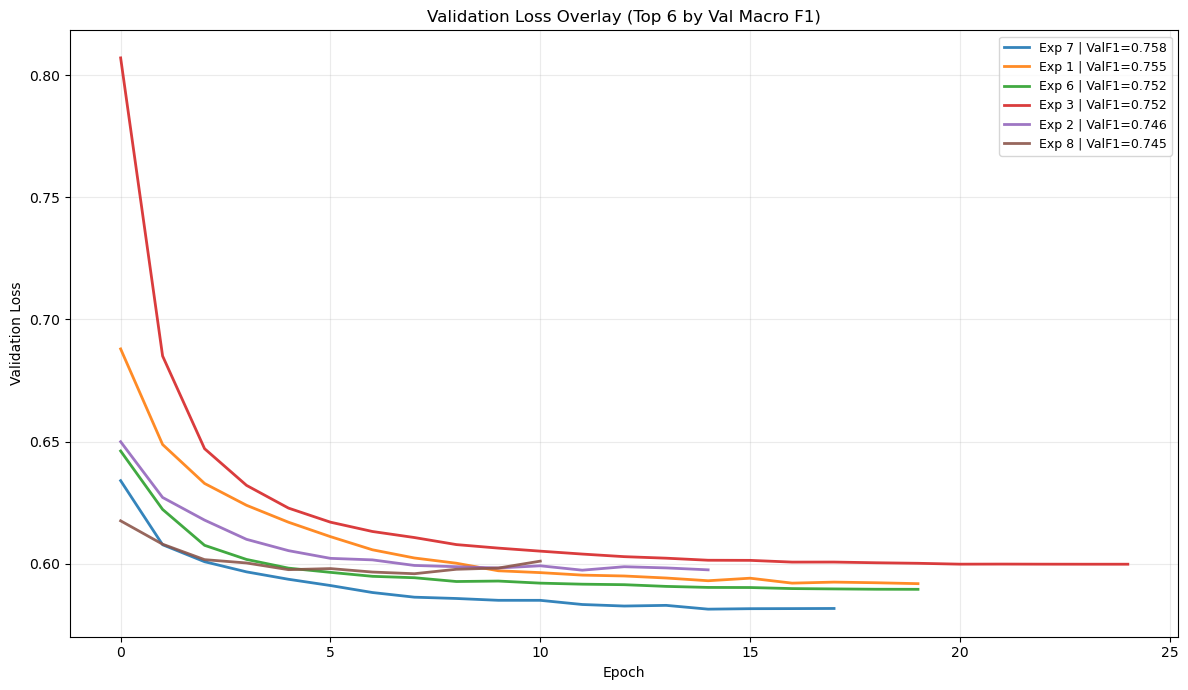

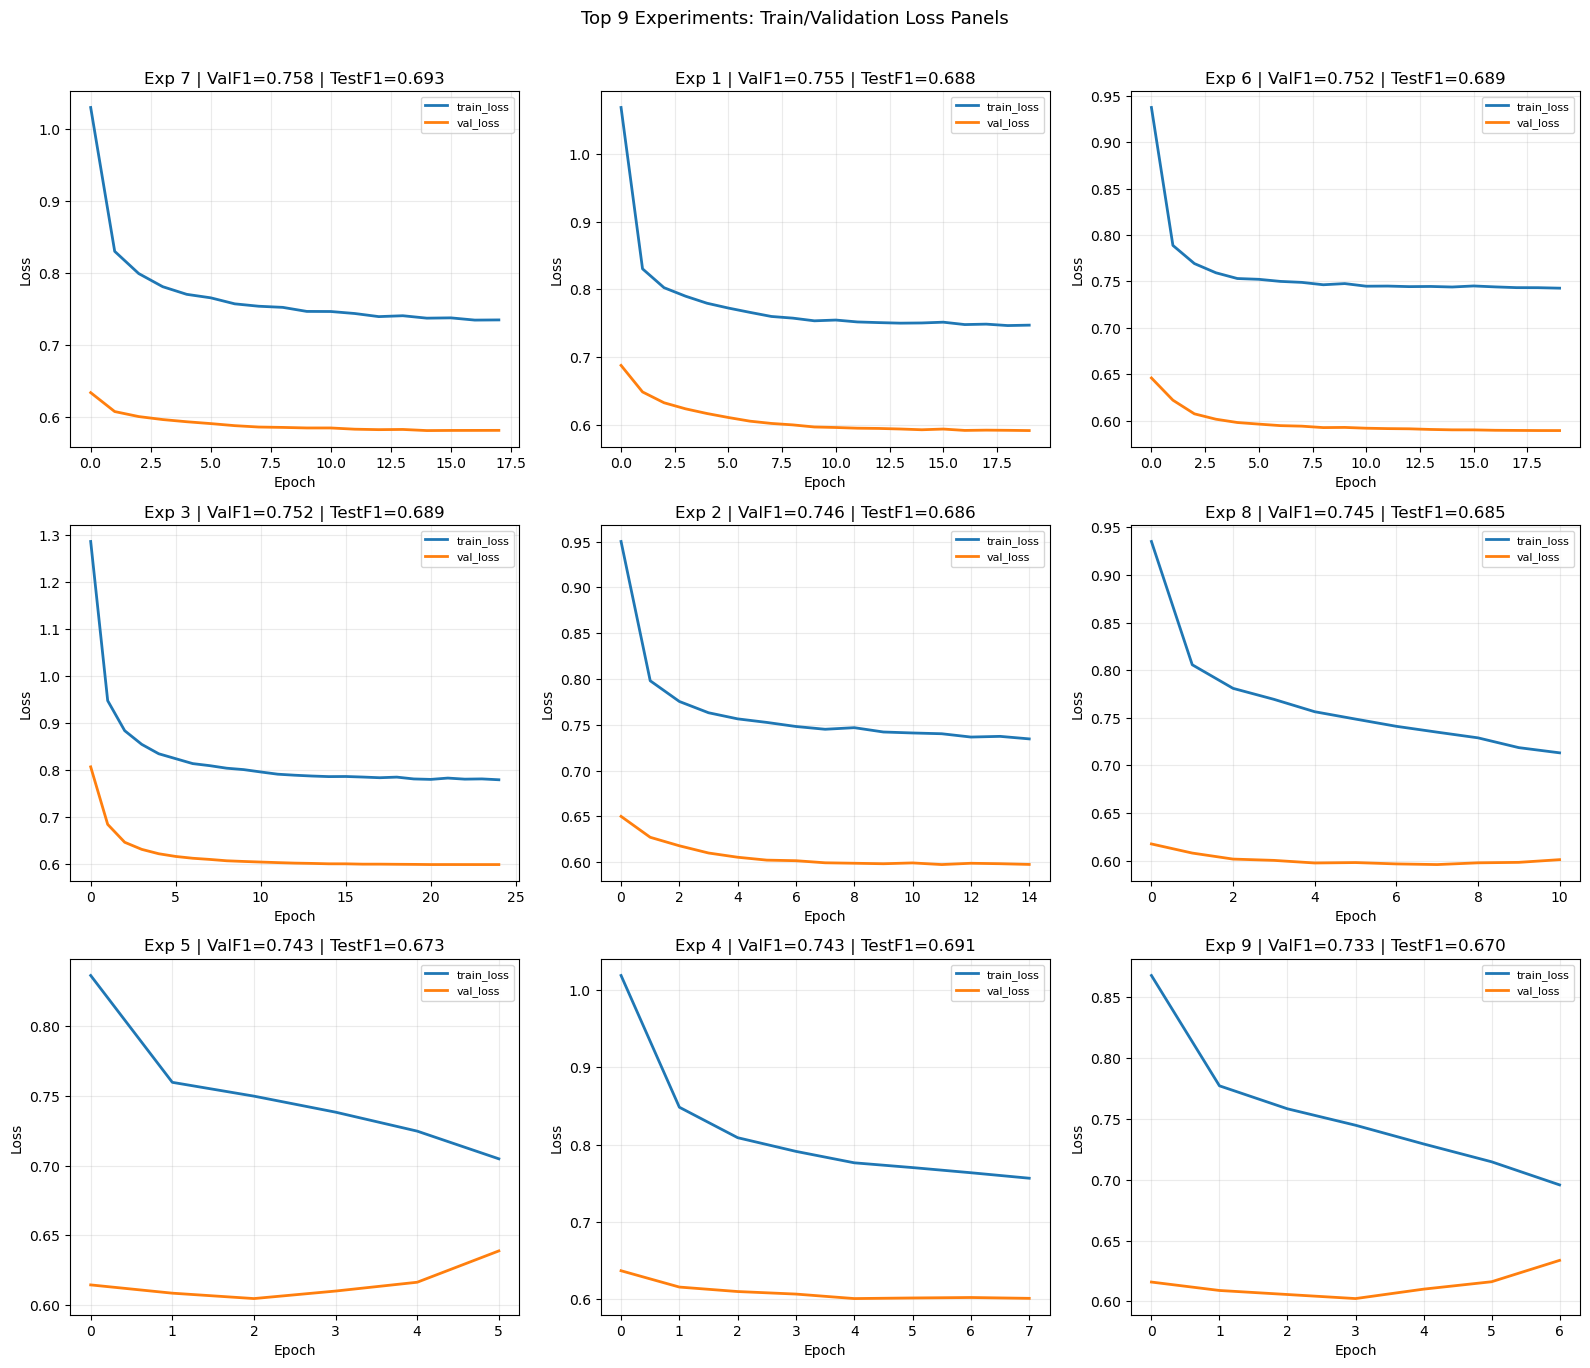

In [ ]:
# ============================================================
# 5. LOSS CURVES FROM HYPERPARAMETER TUNING
# ============================================================
def _get_plot_ready_histories(hyperparameters_df, histories_list, sort_col='Val Macro F1'):
    if 'sweep_histories' not in globals() or len(histories_list) == 0:
        raise ValueError("No histories available. Re-run the tuning loop to repopulate sweep_histories.")

    df = hyperparameters_df.reset_index(drop=True).copy()
    n = min(len(df), len(histories_list))
    if n == 0:
        raise ValueError("No aligned rows between hyperparameters and sweep_histories.")

    if len(df) != len(histories_list):
        print(f"Warning: rows ({len(df)}) and histories ({len(histories_list)}) differ. Using first {n} aligned entries.")

    df = df.iloc[:n].copy()
    df['history_idx'] = range(n)
    if sort_col in df.columns:
        df = df.sort_values(sort_col, ascending=False).reset_index(drop=True)

    return df


def plot_loss_overlay(hyperparameters_df, histories_list, top_k=6, sort_col='Val Macro F1'):
    ranked = _get_plot_ready_histories(hyperparameters_df, histories_list, sort_col=sort_col)
    top = ranked.head(top_k)

    plt.figure(figsize=(12, 7))
    for _, row in top.iterrows():
        h = histories_list[int(row['history_idx'])]
        label = f"Exp {int(row.get('Experiment', row['history_idx'] + 1))} | ValF1={row.get('Val Macro F1', np.nan):.3f}"
        if 'val_loss' in h:
            plt.plot(h['val_loss'], linewidth=2, alpha=0.9, label=label)

    plt.title(f"Validation Loss Overlay (Top {len(top)} by {sort_col})")
    plt.xlabel('Epoch')
    plt.ylabel('Validation Loss')
    plt.grid(True, alpha=0.25)
    plt.legend(loc='best', fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_loss_grid_9(hyperparameters_df, histories_list, sort_col='Val Macro F1'):
    ranked = _get_plot_ready_histories(hyperparameters_df, histories_list, sort_col=sort_col)
    top = ranked.head(9)

    n = len(top)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.5 * nrows), sharex=False, sharey=False)
    axes = np.atleast_1d(axes).ravel()

    for ax_i, (_, row) in enumerate(top.iterrows()):
        ax = axes[ax_i]
        h = histories_list[int(row['history_idx'])]

        if 'loss' in h:
            ax.plot(h['loss'], label='train_loss', linewidth=2)
        if 'val_loss' in h:
            ax.plot(h['val_loss'], label='val_loss', linewidth=2)

        exp_num = int(row.get('Experiment', row['history_idx'] + 1))
        val_f1 = row.get('Val Macro F1', np.nan)
        test_f1 = row.get('Test Macro F1', np.nan)
        ax.set_title(f"Exp {exp_num} | ValF1={val_f1:.3f} | TestF1={test_f1:.3f}")
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8)

    for ax in axes[n:]:
        ax.axis('off')

    fig.suptitle(f"Top {n} Experiments: Train/Validation Loss Panels", y=1.01, fontsize=13)
    plt.tight_layout()
    plt.show()


# Option 1: one figure, multiple series
plot_loss_overlay(hyperparameters, sweep_histories, top_k=6, sort_col='Val Macro F1')

# Option 2: up to 9 separate panels
plot_loss_grid_9(hyperparameters, sweep_histories, sort_col='Val Macro F1')


Final sequence sizes:  (79530, 14, 7) (18150, 14, 7) (17985, 14, 7)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 128)            │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,925 (288.77 KB)

 Trainable params: 73,925 (288.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1243/1243 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.5453 - loss: 1.0463 - val_accuracy: 0.7450 - val_loss: 0.6282
Epoch 2/30
1243/1243 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.6282 - loss: 0.8391 - val_accuracy: 0.7513 - val_loss: 0.6082
Epoch 3/30
1243/1243 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.6425 - loss: 0.8047 - val_accuracy: 0.7533 - val_loss: 0.6007
Epoch 4/30
1243/1243 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.6504 - loss: 0.7842 - val_accuracy: 0.7544 - val_loss: 0.5979
Epoch 5/30
1243/1243 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.6541 - loss: 0.7743 - val_accuracy: 0.7571 - val_loss: 0.5955
Epoch 6/30
1243/1243 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.6585 - loss: 0.7652 - val_accuracy: 0.7559 - val_loss: 0.5917
Epoch 7/30
1243/1243 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.6606 - loss: 0.7602 - val_accuracy: 0.7606 - val_loss: 0.5905
Epoch 8/30
1243/1243 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.6640 -

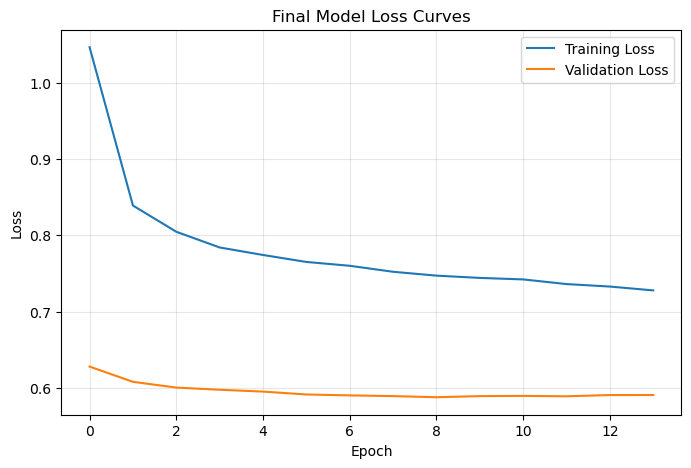

In [ ]:
# ============================================================
# 6. USE BEST HYPERPARAMETERS TO CREATE FINAL LSTM MODEL
# ============================================================
# best hyperparameter configuration
best_config = {
    'lookback': 14,         # Strongest signal in the sweep — best Val and Test Macro F1
                            # by ~0.011 over lookback=7. Consistent across Exps 3 and 7,
                            # both of which outperform all lookback=7 experiments.

    'units': 128,           # Exp 7 (128 units, lookback=14) outperforms Exp 3 (64 units,
                            # lookback=14) on every metric. The aggregated units=32 lead
                            # is a confound with lookback=3, not a genuine signal.

    'dropout': 0.3,         # Consistent across all top experiments. Dropout=0.2 leads
                            # on Val F1 in the aggregate table but is confounded with
                            # lookback=3 experiments. For lookback=14 + units=128,
                            # 0.3 is the only tested value and the loss curves show
                            # no overfitting, so no reason to deviate.

    'batch_size': 64,       # Batch=32 leads slightly on Val Macro F1 but at roughly
                            # 2x the compute cost per epoch and no meaningful Test F1
                            # advantage. Batch=64 is used in both top experiments
                            # (Exps 3 and 7) and gives stable training.

    'lr': 3e-4,             # Exp 7's lr. After batch scaling (3e-4 * 64/64 = 3e-4),
                            # this sits in the sweet spot — cosine decay with warmup
                            # means the effective LR starts low anyway, so a slightly
                            # higher base LR is appropriate here vs Exp 3's 1e-4.

    'lr_schedule': 'cosine', # Cosine outperforms constant on both Val and Test Macro F1
                             # in the aggregated table (0.751 vs 0.743 Val F1), and all
                             # top-performing experiments use cosine.

    'warmup': 100,          # Warmup=100 is the best level on both Val and Test Macro F1
                            # by a clear margin. Shared by both Exps 3 and 7 — the most
                            # consistent signal in the entire sweep.

    'weight_decay': 0.0,    # All experiments used 0.0 after dropping the weight_decay
                            # experiments, so there is no basis to deviate. No overfitting
                            # was observed in the top experiments' loss curves anyway.

    'momentum': 0.9,        # Exp 7 uses 0.9 and it contributes to faster early
                            # convergence visible in the loss curve. The aggregated
                            # table shows a small Val F1 advantage for 0.9 (0.751 vs
                            # 0.746). Exp 3 uses 0.0 and converges more slowly —
                            # this is a deliberate deviation from Exp 3 toward Exp 7.

    'init': 'he_normal',    # he_normal leads on Test Macro F1 and Test MAE in the
                            # aggregated table, and is used in both Exps 3 and 7.
                            # Appropriate for ReLU activations in the dense layers.

    'epochs': 30            # Deviation from both experiments: Exp 7 trained 18 epochs
                            # and Exp 3 trained 25. Setting 30 gives the final model
                            # a slightly wider ceiling since this is the full training
                            # run (not a sweep). Early stopping with patience=5
                            # (recommend increasing from sweep's patience=3) will
                            # prevent overtraining — the extra headroom costs nothing
                            # if the model converges early.
}

# Sanity check
if any(v is None for v in best_config.values()):
    raise ValueError("Please fill all entries in best_config before running this cell.")

# Build sequences for final training (uses same train_base/val_base/test_base as tuning)
lookback = best_config['lookback']
X_train_final, y_train_final = create_sequences(train_base, FEATURES, 'target_lstm', lookback)
X_val_final, y_val_final = create_sequences(val_base, FEATURES, 'target_lstm', lookback)
X_test_final, y_test_final = create_sequences(test_base, FEATURES, 'target_lstm', lookback)

print("Final sequence sizes: ", X_train_final.shape, X_val_final.shape, X_test_final.shape)

# scale LR by batch size (use same reference as sweep)
base_lr = best_config['lr']
batch_size = best_config['batch_size']
lr = base_lr * (batch_size / 64)
total_steps = int(best_config['epochs'] * np.ceil(X_train_final.shape[0] / batch_size))
lr_sched = make_lr_schedule(lr, warmup_steps=best_config['warmup'], total_steps=total_steps, schedule=best_config['lr_schedule'])

# initializer and optimizer (prefer AdamW when available)
initializer = tf.keras.initializers.get(best_config['init'])
try:
    Optim = tf.keras.optimizers.experimental.AdamW
    optimizer = Optim(learning_rate=lr_sched if callable(lr_sched) else lr_sched, weight_decay=best_config['weight_decay'], beta_1=best_config['momentum'])
except Exception:
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_sched if callable(lr_sched) else lr_sched)

# Build final model
final_model = Sequential([
    Input(shape=(lookback, len(FEATURES))),
    LSTM(best_config['units'], kernel_initializer=initializer),
    Dropout(best_config['dropout']),
    Dense(32, activation='relu', kernel_initializer=initializer),
    Dropout(0.20),
    Dense(5, activation='softmax', kernel_initializer=initializer)
])
final_model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
final_model.summary()

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train final model
final_history = final_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val_final, y_val_final),
    epochs=best_config['epochs'],
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=1,
)

# Evaluate and report
test_probs = final_model.predict(X_test_final)
test_preds = np.argmax(test_probs, axis=1)
print("\nFinal model evaluation on test set:")
print(classification_report(y_test_final, test_preds, labels=[0,1,2,3,4], target_names=['HVI 1','HVI 2','HVI 3','HVI 4','HVI 5'], zero_division=0))
print('Accuracy:', accuracy_score(y_test_final, test_preds))
print('Macro F1:', f1_score(y_test_final, test_preds, average='macro', zero_division=0))
print('Weighted F1:', f1_score(y_test_final, test_preds, average='weighted', zero_division=0))
print('Mean Abs Class Error:', mean_absolute_error(y_test_final+1, test_preds+1))

# Loss curves for the final model
plt.figure(figsize=(8,5))
plt.plot(final_history.history['loss'], label='Training Loss')
plt.plot(final_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Final Model Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# ============================================================
# 7. EXPORT & SAVE MODEL AND PREDICTIONS LOCALLY 
# saves model predictions and model to use in future visualization script
# ============================================================
art_dir = Path('artifacts')
art_dir.mkdir(exist_ok=True)

# Determine lookback
if 'best_config' in globals() and best_config.get('lookback'):
    _lookback = int(best_config['lookback'])
elif 'lookback' in globals():
    _lookback = int(lookback)
else:
    _lookback = 14

# If padded sequences not present, build them (vectorized per-zip)
def _create_padded_sequences(df, features, lookback):
    df = df.sort_values(['zip','date']).copy()
    pad = lookback - 1
    rows = []
    idx = []
    for z, g in df.groupby('zip'):
        g = g.reset_index(drop=True)
        vals = g[features].values
        if vals.shape[0] == 0:
            continue
        if pad > 0:
            pad_arr = np.repeat(vals[[0]], pad, axis=0)
            padded = np.vstack([pad_arr, vals])
        else:
            padded = vals
        for i in range(pad, padded.shape[0]):
            rows.append(padded[i - (lookback - 1): i + 1])
            orig_idx = i - pad
            idx.append({'zip': str(z), 'date': g.loc[orig_idx, 'date']})
    if len(rows) == 0:
        return np.empty((0, lookback, len(features))), pd.DataFrame(columns=['zip','date'])
    return np.array(rows), pd.DataFrame(idx)

# Ensure lstm_df exists
if 'lstm_df' not in globals():
    raise RuntimeError('lstm_df not found; run preprocessing cells first')

df_all = lstm_df.copy()
df_all['date'] = pd.to_datetime(df_all['date'])
df_all['zip'] = df_all['zip'].astype(str)

# Apply scaler to features for model input if scaler exists
if 'scaler_exp' in globals():
    try:
        df_all[FEATURES] = scaler_exp.transform(df_all[FEATURES])
    except Exception:
        # If scaler wasn't fit on same index, fallback to transforming by groups
        df_all[FEATURES] = df_all[FEATURES]

# Build padded sequences if not in memory
if 'X_pad' not in globals() or 'idx_pad' not in globals():
    X_pad, idx_pad = _create_padded_sequences(df_all, FEATURES, _lookback)
else:
    X_pad_local = X_pad
    idx_pad_local = idx_pad
    X_pad, idx_pad = X_pad_local, idx_pad_local

if X_pad.shape[0] == 0:
    raise RuntimeError('No padded sequences generated; check lstm_df and FEATURES')

# Run prediction once
probs = final_model.predict(X_pad, verbose=0)
lstm_preds = probs.argmax(axis=1) + 1

# Build preds_full DataFrame
preds_full = idx_pad.copy()
preds_full['date'] = pd.to_datetime(preds_full['date'])
preds_full['zip'] = preds_full['zip'].astype(str)
preds_full['lstm_pred'] = lstm_preds
for i in range(probs.shape[1]):
    preds_full[f'lstm_prob_{i+1}'] = probs[:, i]

# Merge original (unscaled) features and ground truth from lstm_df
lstm_src = lstm_df.copy()
lstm_src['date'] = pd.to_datetime(lstm_src['date'])
lstm_src['zip'] = lstm_src['zip'].astype(str)
merge_on = ['zip','date']

out = preds_full.merge(lstm_src[merge_on + FEATURES + ['temporal_hvi_target']], on=merge_on, how='left')
out = out.rename(columns={'temporal_hvi_target': 'ground_truth_hvi'})

# Merge other model preds if available
if 'model_df' in globals():
    model_preds = model_df[['zip','date','predicted_temporal_hvi_xgb','predicted_temporal_hvi_dt','predicted_temporal_hvi_rf']].copy()
    model_preds['date'] = pd.to_datetime(model_preds['date'])
    model_preds['zip'] = model_preds['zip'].astype(str)
    out = out.merge(model_preds, on=merge_on, how='left')
    out = out.rename(columns={'predicted_temporal_hvi_xgb':'xgb_pred','predicted_temporal_hvi_dt':'dt_pred','predicted_temporal_hvi_rf':'rf_pred'})
else:
    out['xgb_pred'] = pd.NA
    out['dt_pred'] = pd.NA
    out['rf_pred'] = pd.NA

# Vectorized model agreement
pred_cols = ['lstm_pred','xgb_pred','dt_pred','rf_pred']
if all(c in out.columns for c in pred_cols):
    not_null = out[pred_cols].notna().all(axis=1)
    same = out[pred_cols].nunique(axis=1) == 1
    out['model_agreement'] = (not_null & same).astype(int)
else:
    out['model_agreement'] = 0

# Reorder and save CSV
prob_cols = [c for c in out.columns if c.startswith('lstm_prob_')]
cols = ['date','zip'] + FEATURES + ['ground_truth_hvi','lstm_pred','xgb_pred','dt_pred','rf_pred'] + prob_cols + ['model_agreement']
cols = [c for c in cols if c in out.columns]
out = out[cols]

csv_path = art_dir / 'predictions_merged.csv'
out.to_csv(csv_path, index=False)
print('Saved merged CSV to', csv_path)

# Save scaler
if 'scaler_exp' in globals():
    with open(art_dir / 'feature_scaler.pkl','wb') as f:
        pickle.dump(scaler_exp, f)
    print('Saved scaler to', art_dir / 'feature_scaler.pkl')

# Save metadata
metadata = {'features': FEATURES, 'best_config': best_config if 'best_config' in globals() else {}, 'class_labels':[1,2,3,4,5], 'date_range':[str(lstm_src['date'].min()), str(lstm_src['date'].max())], 'n_zips': int(lstm_src['zip'].nunique())}
with open(art_dir / 'model_config.json','w') as f:
    json.dump(metadata, f, indent=2)
print('Saved metadata to', art_dir / 'model_config.json')

# Rebuild fresh model (no optimizer), copy weights, export SavedModel + .keras

lookback_local = _lookback
units_local = int(best_config.get('units',128)) if 'best_config' in globals() else 128
dropout_local = float(best_config.get('dropout',0.3)) if 'best_config' in globals() else 0.3
initializer = tf.keras.initializers.get(best_config.get('init','he_normal')) if 'best_config' in globals() else tf.keras.initializers.HeNormal()

fresh = Sequential([Input(shape=(lookback_local, len(FEATURES))), LSTM(units_local, kernel_initializer=initializer), Dropout(dropout_local), Dense(32, activation='relu', kernel_initializer=initializer), Dropout(0.2), Dense(5, activation='softmax')])
fresh.set_weights(final_model.get_weights())

# TF SavedModel
sm_dir = art_dir / 'final_lstm_savedmodel'
try:
    tf.saved_model.save(fresh, str(sm_dir))
    print('Saved TensorFlow SavedModel to', sm_dir)
except Exception as e:
    print('SavedModel save failed:', e)

# Inference .keras
keras_path = art_dir / 'final_lstm_model_inference.keras'
try:
    fresh.save(str(keras_path), include_optimizer=False)
    print('Saved inference .keras to', keras_path)
except Exception as e:
    print('Could not save .keras file:', e)

print('Export complete — artifacts in', art_dir)


### The figure below was mostly for my own sanity to check that the LSTM model was actually doing something. We could add it to the future visualization script or we could leave it here (and use it as a gut check to say our model is doing something) or we could also just delete it since the visualizations themselves aren't anything too crazy

Top 3 variable ZIPs: [10460, 10451, 11435]


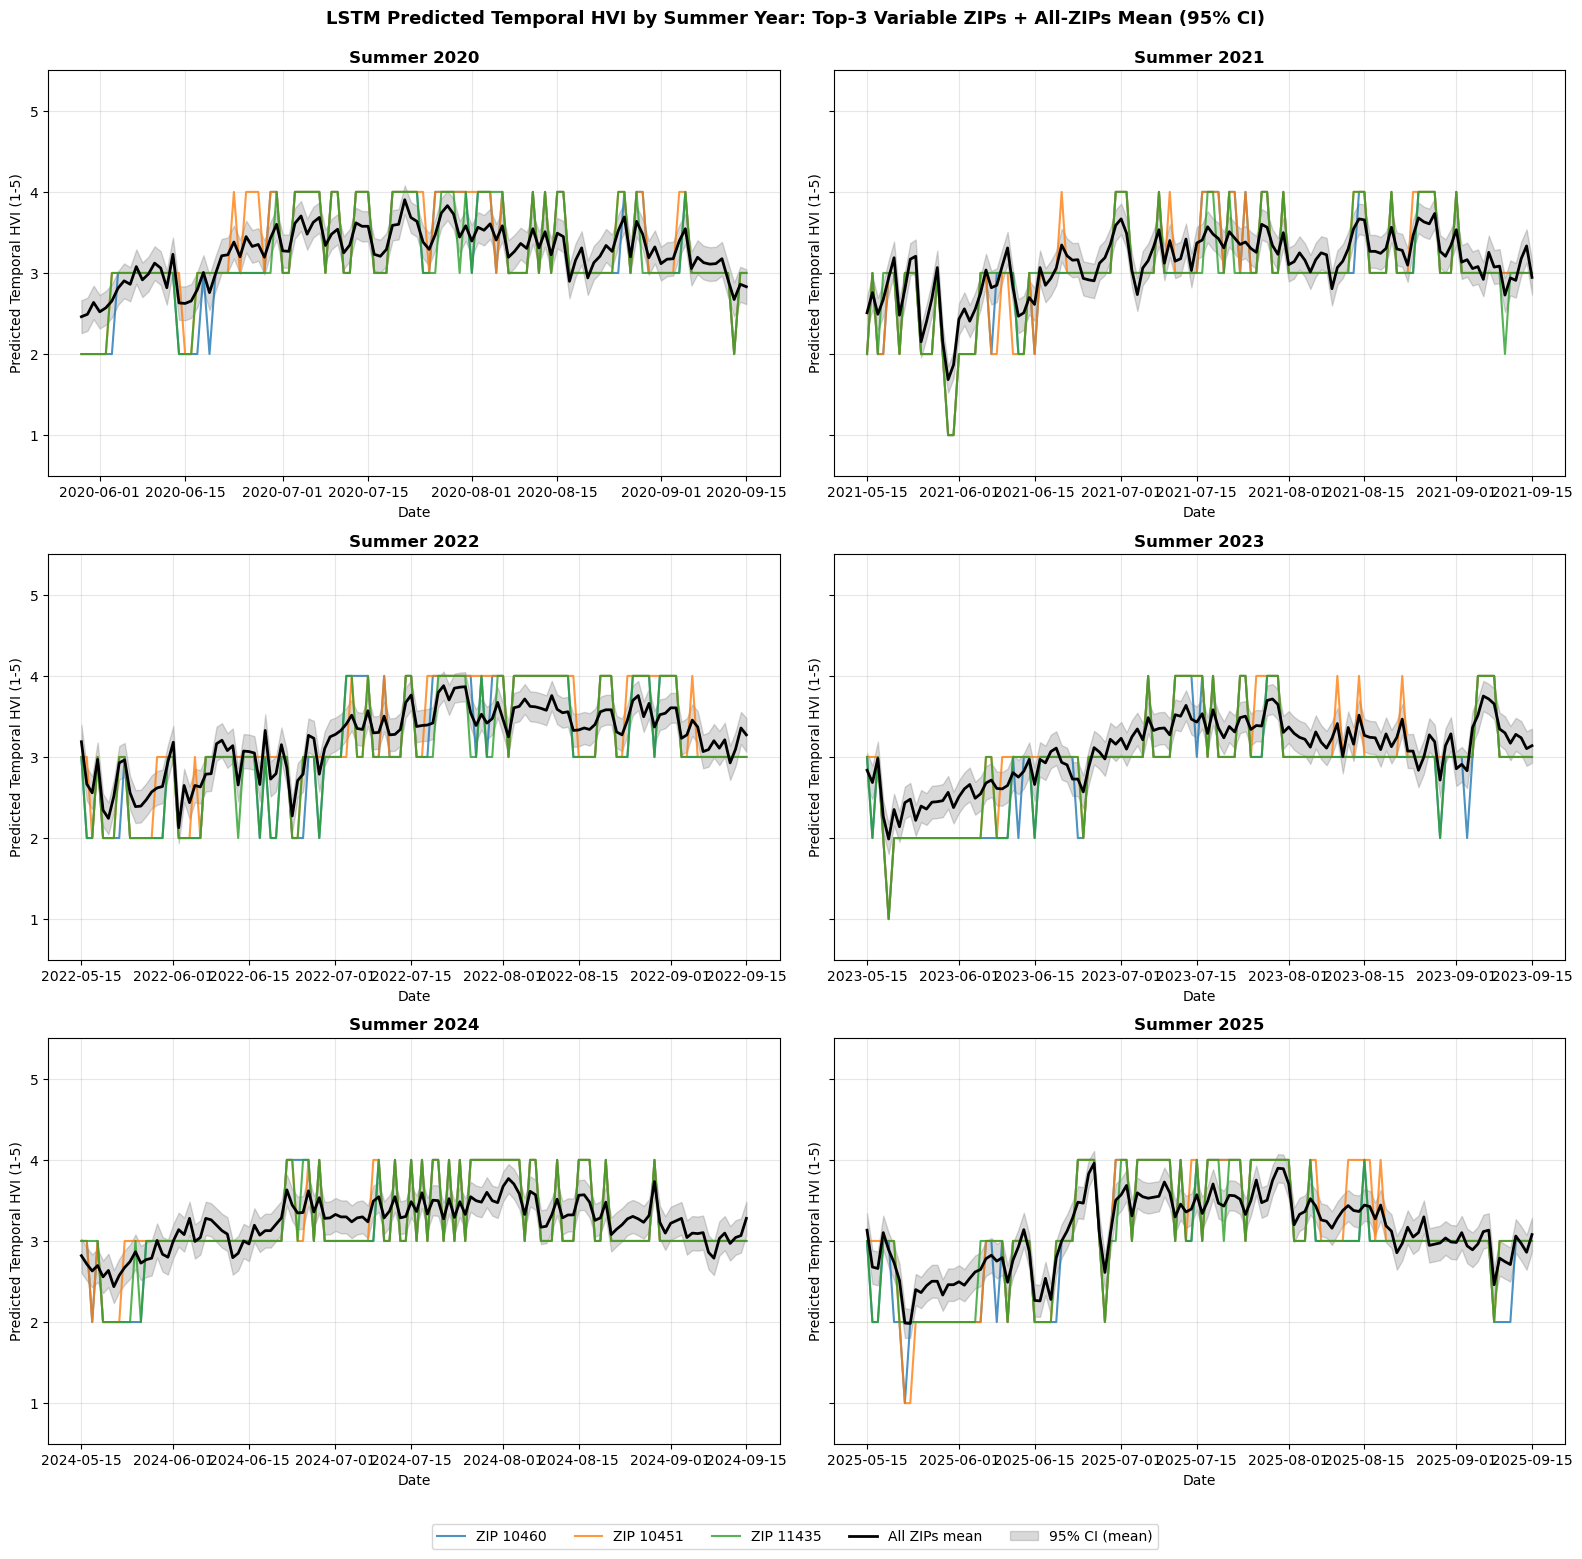

In [ ]:
# ============================================================
# TIMESERIES: Final LSTM Predictions for Top-3 Most Variable ZIPs + Overall Mean with CI
# Compatible with consolidated exporter: uses `out` (merged CSV DF) or falls back to `preds_full`/`preds_df`.
# One subplot per summer year (2020-2025)
# ============================================================

# Obtain a dataframe with columns: date, zip, pred
if 'out' in globals() and isinstance(out, pd.DataFrame):
    src = out.copy()
    if 'lstm_pred' in src.columns:
        src = src.rename(columns={'lstm_pred': 'pred'})
    elif 'pred' not in src.columns:
        raise RuntimeError('Merged dataframe `out` does not contain `lstm_pred` or `pred`.')
    preds_df_local = src[['date', 'zip', 'pred']].copy()
elif 'preds_full' in globals():
    preds_df_local = preds_full[['date', 'zip', 'lstm_pred']].rename(columns={'lstm_pred':'pred'}).copy()
elif 'preds_df' in globals():
    preds_df_local = preds_df.copy()
else:
    raise RuntimeError('No prediction dataframe found. Run the consolidated export cell first to produce `out` or `preds_full`.')

# Ensure types are correct
preds_df_local['date'] = pd.to_datetime(preds_df_local['date'])
preds_df_local['zip'] = preds_df_local['zip'].astype(str)
preds_df_local['year'] = preds_df_local['date'].dt.year

# Compute per-zip variability (fallback to model_df if available)
if 'variability_df' in globals():
    var_series = variability_df.copy()
else:
    # compute std of predictions per ZIP across available dates
    var_series = preds_df_local.groupby('zip')['pred'].std().dropna()

if var_series.empty:
    raise RuntimeError('Could not compute variability per zip.')

top_zips = var_series.sort_values(ascending=False).head(3).index.tolist()
print(f'Top 3 variable ZIPs: {top_zips}')

# Create subplots (one per year)
years = sorted(preds_df_local['year'].unique())
n_years = len(years)
if n_years == 0:
    raise RuntimeError('No years found in predictions.')

ncols = 2
nrows = int(np.ceil(n_years / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows), sharex=False, sharey=True)
axes = np.atleast_1d(axes).ravel()

colors = ['C0', 'C1', 'C2']

for year_idx, year in enumerate(years):
    ax = axes[year_idx]
    year_preds = preds_df_local[preds_df_local['year'] == year].copy()

    # Build daily per-zip mean predicted class for this year
    daily_per_zip_year = (
        year_preds.groupby(['date', 'zip'])['pred']
        .mean()
        .reset_index()
    )

    # Compute overall daily mean across zips and 95% CI for this year
    daily_summary_year = (
        daily_per_zip_year.groupby('date')['pred']
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )

    daily_summary_year['sem'] = daily_summary_year['std'] / np.sqrt(daily_summary_year['count'].replace(0, np.nan))
    daily_summary_year['ci95'] = 1.96 * daily_summary_year['sem'].fillna(0)

    # Pivot per-zip for plotting
    pivot_year = daily_per_zip_year.pivot(index='date', columns='zip', values='pred')

    dates = daily_summary_year['date']
    mean = daily_summary_year['mean']
    ci = daily_summary_year['ci95']

    # Plot top-3 ZIPs
    for i, z in enumerate(top_zips):
        z_str = str(z)
        if z_str in pivot_year.columns:
            ax.plot(pivot_year.index, pivot_year[z_str], label=f'ZIP {z_str}', color=colors[i], alpha=0.8, linewidth=1.5)

    # Plot overall mean with CI
    ax.plot(dates, mean, label='All ZIPs mean', color='k', linewidth=2)
    ax.fill_between(dates, mean - ci, mean + ci, color='k', alpha=0.15, label='95% CI (mean)')

    ax.set_title(f'Summer {year}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Predicted Temporal HVI (1-5)')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.5, 5.5)

# Turn off unused subplots
for ax in axes[n_years:]:
    ax.axis('off')

# Add legend (from first subplot)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5, fontsize=10, bbox_to_anchor=(0.5, -0.01))

fig.suptitle('LSTM Predicted Temporal HVI by Summer Year: Top-3 Variable ZIPs + All-ZIPs Mean (95% CI)', fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()